## Preparation

In [149]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torch.nn as nn
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.model_selection import GroupShuffleSplit, train_test_split
import pandas as pd
import pickle
import sys
import math
import random
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist, squareform

In [6]:
!{sys.executable} -m pip install -q "pyarrow>=13.0.0"

df = pd.read_pickle(
    r"C:\Users\Juli\Documents\Master\Projekt Genomforschung\Datasets\harmonized_data.pkl"
)

## Models

We use the cross-attention fusion model.

In [3]:
class CrossAttentionFusionModel(nn.Module):
    def __init__(self, gene_dim=978, chem_dim=1032, hidden_dim=32, num_tokens=4, num_heads=4, dropout=0.3):
        super().__init__()
        self.num_tokens = num_tokens
        self.hidden_dim = hidden_dim
        
        self.input_dropout_gene = nn.Dropout(0.2)
        self.input_dropout_chem = nn.Dropout(0.3)

        self.gene_encoder = nn.Sequential(
            nn.Linear(gene_dim, num_tokens * hidden_dim),
            nn.BatchNorm1d(num_tokens * hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.drug_encoder = nn.Sequential(
            nn.Linear(chem_dim, num_tokens * hidden_dim),
            nn.BatchNorm1d(num_tokens * hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        # Cross-attention mechanism using 4 attention heads.
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        # Layer normalization for gene and drug tokens after cross-attention.
        self.norm_gene = nn.LayerNorm(hidden_dim)
        self.norm_drug = nn.LayerNorm(hidden_dim)
        # Final regressor that takes the concatenated gene and drug representations and outputs a single prediction.
        # Multi-Layer Perceptron (MLP)
        self.regressor = nn.Sequential(
            nn.Linear(num_tokens * hidden_dim * 2, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )
    
    def forward(self, x_gene, x_drug):
        batch_size = x_gene.size(0)
        x_gene = self.input_dropout_gene(x_gene)
        x_drug = self.input_dropout_chem(x_drug)

        gene_tokens = self.gene_encoder(x_gene).view(batch_size, self.num_tokens, self.hidden_dim)
        drug_tokens = self.drug_encoder(x_drug).view(batch_size, self.num_tokens, self.hidden_dim)

        gene_attn_out, gene_attn_weights = self.cross_attn(
            query=gene_tokens, key=drug_tokens, value=drug_tokens
        )
        drug_attn_out, drug_attn_weights = self.cross_attn(
            query=drug_tokens, key=gene_tokens, value=gene_tokens
        )
        self.last_attn_weights = {
            "gene_to_drug": gene_attn_weights.detach().cpu().numpy(),
            "drug_to_gene": drug_attn_weights.detach().cpu().numpy(),
        }

        gene_context = self.norm_gene(gene_tokens + gene_attn_out)
        drug_context = self.norm_drug(drug_tokens + drug_attn_out)

        fused = torch.cat(
            [gene_context.view(batch_size, -1), drug_context.view(batch_size, -1)],
            dim=1
        )
        pred = self.regressor(fused)
        return pred.squeeze(1)

In [3]:
class AdvancedSelfAndCrossAttentionModel(nn.Module):
    def __init__(self, gene_dim=978, chem_dim=1032, hidden_dim=64, num_heads=4, num_tokens=8, dropout=0.3):
        super().__init__()
        
        self.hidden_dim = hidden_dim
        self.num_tokens = num_tokens
        
        # encoder: Projizieren die flachen Features in eine Token-Sequenz (Batch, num_tokens, hidden_dim)
        self.gene_encoder = nn.Sequential(
            nn.Linear(gene_dim, num_tokens * hidden_dim),
            nn.LayerNorm(num_tokens * hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.drug_encoder = nn.Sequential(
            nn.Linear(chem_dim, num_tokens * hidden_dim),
            nn.LayerNorm(num_tokens * hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        # Positional Encoding (Optional, aber hilfreich, damit die Attention die Token-IDs unterscheiden kann)
        self.gene_pos = nn.Parameter(torch.randn(1, num_tokens, hidden_dim))
        self.drug_pos = nn.Parameter(torch.randn(1, num_tokens, hidden_dim))

        # 2. SELF-ATTENTION: Jede Modalität kommuniziert erst mit sich selbst
        self.gene_self_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim, num_heads=num_heads, dropout=dropout, batch_first=True
        )
        self.drug_self_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim, num_heads=num_heads, dropout=dropout, batch_first=True
        )
        
        self.norm_self_gene = nn.LayerNorm(hidden_dim)
        self.norm_self_drug = nn.LayerNorm(hidden_dim)

        # 3. CROSS-ATTENTION: Chemie fragt Biologie ab
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim, num_heads=num_heads, dropout=dropout, batch_first=True
        )
        self.norm_cross = nn.LayerNorm(hidden_dim)

        # 4. REGRESSION HEAD
        self.regressor = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x_gene, x_drug):
        batch_size = x_gene.size(0)

        # --- Schritt 1: In Tokens transformieren ---
        # Shape: (B, num_tokens, hidden_dim)
        gene_tokens = self.gene_encoder(x_gene).view(batch_size, self.num_tokens, self.hidden_dim)
        drug_tokens = self.drug_encoder(x_drug).view(batch_size, self.num_tokens, self.hidden_dim)
        
        # Positional Embedding addieren
        gene_tokens = gene_tokens + self.gene_pos
        drug_tokens = drug_tokens + self.drug_pos

        # --- Schritt 2: Echte Self-Attention (Intra-modal) ---
        # Biologie filtert eigenes Rauschen
        gene_self_out, _ = self.gene_self_attn(query=gene_tokens, key=gene_tokens, value=gene_tokens)
        gene_tokens = self.norm_self_gene(gene_tokens + gene_self_out)

        # Chemie ordnet funktionelle Gruppen aneinander an
        drug_self_out, _ = self.drug_self_attn(query=drug_tokens, key=drug_tokens, value=drug_tokens)
        drug_tokens = self.norm_self_drug(drug_tokens + drug_self_out)

        # --- Schritt 3: Cross-Attention (Inter-modal) ---
        # Chemie (Query) greift auf biologischen Kontext (Key/Value) zu
        cross_out, _ = self.cross_attn(query=drug_tokens, key=gene_tokens, value=gene_tokens)
        drug_context = self.norm_cross(drug_tokens + cross_out)

        # --- Schritt 4: Pooling & Fusion ---
        # Wir mitteln über die Token-Dimension (Mean Pooling)
        gene_repr = gene_tokens.mean(dim=1)  # Shape: (B, hidden_dim)
        drug_repr = drug_context.mean(dim=1) # Shape: (B, hidden_dim)

        # Konkatenerieren zu (B, hidden_dim * 2)
        fused = torch.cat([gene_repr, drug_repr], dim=1)

        # Vorhersage
        pred = self.regressor(fused)
        return pred.squeeze(1)

Der DataLoader kümmert sich darum, dass das Modell die Daten in Batches bekommt

## Training data

In [7]:
# training data group split in train val
target = 'LN_IC50'
pharmacophores = ['Donor', 'Acceptor', 'Aromatic', 'Hydrophobe', 'LumpedHydrophobe', 'PosIonizable', 'NegIonizable', 'ZnBinder']
mfp_cols = [col for col in df.columns if col.startswith('Bit_')]
X_genomic = df.filter(regex=r'.* \(.*\)').values.astype('float32')
X_chem = df[pharmacophores + mfp_cols]
y = df[target].values.astype('float32')

# split data into train and test
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=6726)
idx_train_val, idx_test = next(gss_test.split(X_genomic, y, groups=df['DRUG_ID']))

# separate validation set from training set
groups_train_val = df['DRUG_ID'].iloc[idx_train_val]
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.11, random_state=42)
idx_train, idx_val = next(gss_val.split(X_genomic[idx_train_val], y[idx_train_val], groups=groups_train_val))

idx_train = idx_train_val[idx_train]
idx_val = idx_train_val[idx_val]

preprocessor = ColumnTransformer(
    transformers=[
        ('pharmacophore', StandardScaler(), pharmacophores),
        #('mfp', PCA(n_components=50, random_state=42), mfp_cols)
        ('mfp', 'passthrough', mfp_cols)
    ],
    remainder='drop'
)
gene_scaler = StandardScaler()

X_genomic_train = gene_scaler.fit_transform(X_genomic[idx_train])
X_chem_train = preprocessor.fit_transform(X_chem.iloc[idx_train])

X_genomic_val = gene_scaler.transform(X_genomic[idx_val])
X_chem_val = preprocessor.transform(X_chem.iloc[idx_val])

X_genomic_test = gene_scaler.transform(X_genomic[idx_test])
X_chem_test = preprocessor.transform(X_chem.iloc[idx_test])

# scale IC50 values
#scaler = StandardScaler()
y_train = y[idx_train]#scaler.fit_transform(y[idx_train].reshape(-1, 1)).flatten()
y_val = y[idx_val]#scaler.transform(y[idx_val].reshape(-1, 1)).flatten()
y_test = y[idx_test]#scaler.transform(y[idx_test].reshape(-1, 1)).flatten()

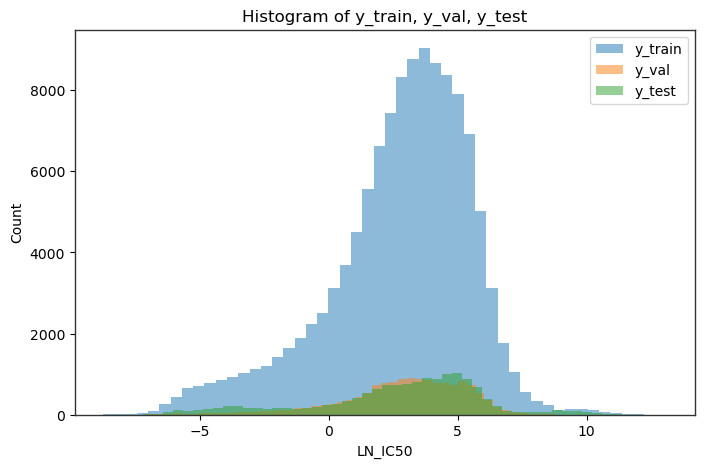

In [99]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(y_train, bins=50, alpha=0.5, label='y_train')
plt.hist(y_val, bins=50, alpha=0.5, label='y_val')
plt.hist(y_test, bins=50, alpha=0.5, label='y_test')
plt.xlabel('LN_IC50')
plt.ylabel('Count')
plt.title('Histogram of y_train, y_val, y_test')
plt.legend()
plt.show()

In [19]:
def make_loaders(batch_size=128, seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    g = torch.Generator()
    g.manual_seed(seed)

    train_loader = DataLoader(
        DrugResponseDataset(X_genomic_train, X_chem_train, y_train),
        batch_size=batch_size,
        shuffle=True,
        drop_last=True,
        generator=g,
    )
    val_loader = DataLoader(
        DrugResponseDataset(X_genomic_val, X_chem_val, y_val),
        batch_size=batch_size,
        shuffle=False,
    )
    test_loader = DataLoader(
        DrugResponseDataset(X_genomic_test, X_chem_test, y_test),
        batch_size=batch_size,
        shuffle=False,
    )
    return train_loader, val_loader, test_loader

class DrugResponseDataset(Dataset):
    def __init__(self, X_gen, X_ch, labels):
        self.X_genomic = torch.tensor(X_gen, dtype=torch.float32)
        self.X_chem = torch.tensor(X_ch if isinstance(X_ch, np.ndarray) else X_ch.values, dtype=torch.float32)
        self.y = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_genomic[idx], self.X_chem[idx], self.y[idx]

## Running 

best_model_7prozent oder so .pt saves the best model (lol) 
It uses these parameters: 
hidden_dim = 32
dropout = 0.5
lr = 1e-3
patience = 6
epochs = 24
weight_decay = 1e-2
num_tokens = 5

In [45]:
# created by copilot
hidden_dim = 32
dropout = 0.5
lr = 1e-3
patience = 6
epochs = 24
weight_decay = 1e-2
num_tokens = 5

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)

set_seed(6726)
train_loader, val_loader, test_loader = make_loaders(batch_size=128, seed=6726)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CrossAttentionFusionModel(
    gene_dim=X_genomic.shape[1],
    chem_dim=X_chem_train.shape[1],
    hidden_dim=hidden_dim,
    num_heads=4,
    dropout=dropout,
    num_tokens=num_tokens
).to(device)

criterion = nn.MSELoss()
#optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=patience
)

best_val_rmse = float("inf")
best_val_r2 = None
best_epoch = -1

print("Start Training")
for epoch in range(epochs):
    model.train()
    train_preds, train_targets = [], []
    train_loss = 0.0

    for batch_genes, batch_chem, batch_y in train_loader:
        batch_genes = batch_genes.to(device)
        batch_chem = batch_chem.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        predictions = model(batch_genes, batch_chem).view(-1)
        batch_y = batch_y.view(-1)

        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * batch_genes.size(0)
        train_preds.extend(predictions.detach().cpu().numpy())
        train_targets.extend(batch_y.detach().cpu().numpy())

    total_train_loss = train_loss / len(train_loader.dataset)
    train_preds_orig = np.array(train_preds)
    train_targets_orig = np.array(train_targets)
    train_rmse_orig = root_mean_squared_error(train_targets_orig, train_preds_orig)

    model.eval()
    val_preds, val_targets = [], []
    val_loss = 0.0

    with torch.no_grad():
        for batch_genes, batch_chem, batch_y in val_loader:
            batch_genes = batch_genes.to(device)
            batch_chem = batch_chem.to(device)
            batch_y = batch_y.to(device)

            predictions = model(batch_genes, batch_chem).view(-1)
            loss = criterion(predictions, batch_y.view(-1))

            val_loss += loss.item() * batch_genes.size(0)
            val_preds.extend(predictions.cpu().numpy())
            val_targets.extend(batch_y.cpu().numpy())

    total_val_loss = val_loss / len(val_loader.dataset)
    val_preds = np.array(val_preds)
    val_targets = np.array(val_targets)
    val_rmse = root_mean_squared_error(val_targets, val_preds)
    val_r2 = r2_score(val_targets, val_preds)

    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_val_r2 = val_r2
        best_epoch = epoch + 1
        torch.save(model.state_dict(), "best_model.pt")

    scheduler.step(total_val_loss)

    print(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"Train RMSE: {train_rmse_orig:.4f} | "
        f"Val RMSE: {val_rmse:.4f} | "
        f"Val R²: {val_r2:.4f}"
    )

model.load_state_dict(torch.load("best_model.pt", weights_only=True))
model.eval()

test_preds, test_targets = [], []
with torch.no_grad():
    for batch_genes, batch_chem, batch_y in test_loader:
        batch_genes = batch_genes.to(device)
        batch_chem = batch_chem.to(device)
        batch_y = batch_y.to(device)

        predictions = model(batch_genes, batch_chem).view(-1)
        test_preds.extend(predictions.cpu().numpy())
        test_targets.extend(batch_y.cpu().numpy())

test_preds = np.array(test_preds)
test_targets = np.array(test_targets)

test_rmse = root_mean_squared_error(test_targets, test_preds)
test_r2 = r2_score(test_targets, test_preds)

print(f"Test RMSE: {test_rmse:.4f} | Test R²: {test_r2:.4f}")
print(
    f"Best model in epoch {best_epoch} with Val RMSE: {best_val_rmse:.4f} "
    f"and Val R²: {best_val_r2:.4f}"
)

Start Training
Epoch 01/24 | Train RMSE: 2.0166 | Val RMSE: 2.7071 | Val R²: -0.1853
Epoch 02/24 | Train RMSE: 1.7564 | Val RMSE: 2.8544 | Val R²: -0.3178
Epoch 03/24 | Train RMSE: 1.7072 | Val RMSE: 2.7492 | Val R²: -0.2225
Epoch 04/24 | Train RMSE: 1.6681 | Val RMSE: 2.8571 | Val R²: -0.3204
Epoch 05/24 | Train RMSE: 1.6440 | Val RMSE: 2.6856 | Val R²: -0.1666
Epoch 06/24 | Train RMSE: 1.6312 | Val RMSE: 2.8807 | Val R²: -0.3423
Epoch 07/24 | Train RMSE: 1.6223 | Val RMSE: 2.6616 | Val R²: -0.1459
Epoch 08/24 | Train RMSE: 1.6069 | Val RMSE: 2.7138 | Val R²: -0.1912
Epoch 09/24 | Train RMSE: 1.6009 | Val RMSE: 2.7879 | Val R²: -0.2572
Epoch 10/24 | Train RMSE: 1.5936 | Val RMSE: 2.5329 | Val R²: -0.0377
Epoch 11/24 | Train RMSE: 1.5902 | Val RMSE: 2.5108 | Val R²: -0.0197
Epoch 12/24 | Train RMSE: 1.5897 | Val RMSE: 2.5781 | Val R²: -0.0751
Epoch 13/24 | Train RMSE: 1.5858 | Val RMSE: 2.6801 | Val R²: -0.1619
Epoch 14/24 | Train RMSE: 1.5801 | Val RMSE: 2.5094 | Val R²: -0.0185
Epoch

## Visualization of results

First visualization of prediction of lnIC50 vs clinical classification. This first plot is not viable because I don't have any reasoning for the threshold. I picked it myself without references.

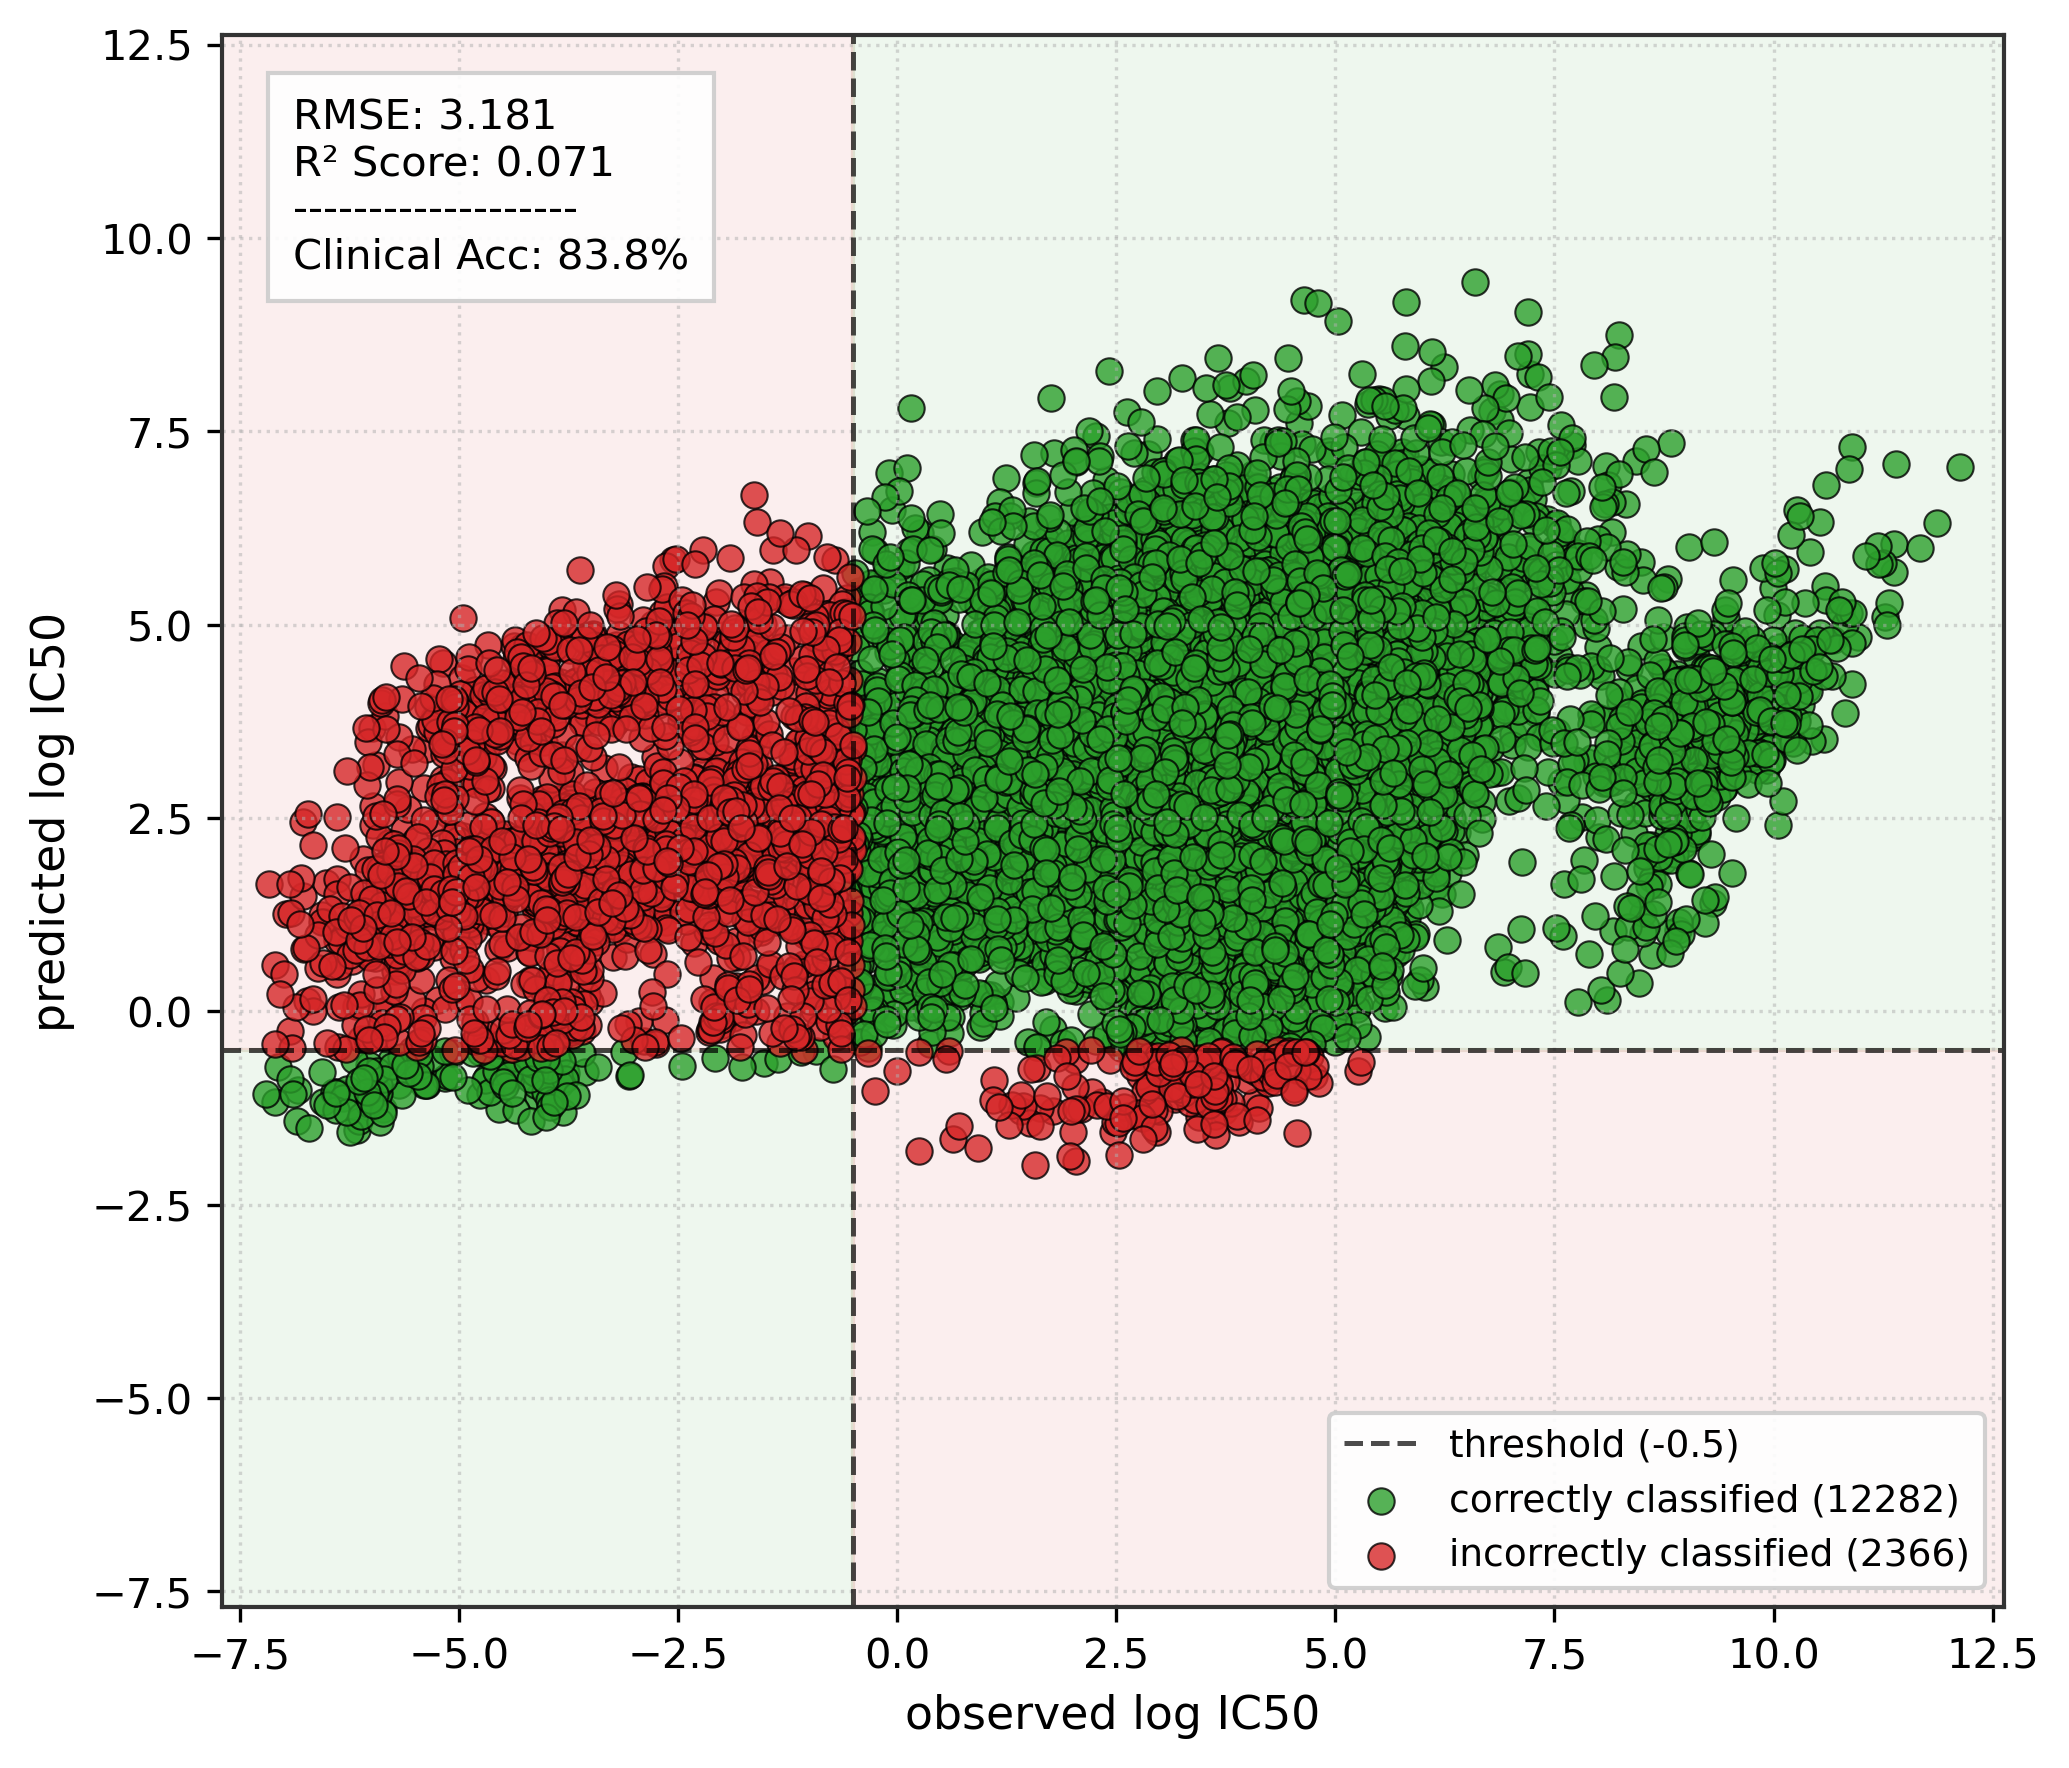

In [107]:
y_true = test_targets
y_pred = test_preds

# clinical parameters - important: i didn't research the clinical threshold, this is just a placeholder for demonstration purposes
THRESHOLD = -0.5  # threshold for sensitive vs resistant
DELTA = 1      # allowed floating-point deviation (tolerance band)

rmse_val = root_mean_squared_error(y_true, y_pred)
r2_val = r2_score(y_true, y_pred)

# Create a scatter plot of predicted vs. true values with a clinical threshold line
val_min = min(np.min(y_true), np.min(y_pred)) - 0.5
val_max = max(np.max(y_true), np.max(y_pred)) + 0.5

#plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 1.0

# threshold-based accuracy calculation
true_bin = (y_true >= THRESHOLD).astype(int)
pred_bin = (y_pred >= THRESHOLD).astype(int)
correct_thresh = (true_bin == pred_bin)
acc_thresh = np.mean(correct_thresh) * 100

fig, ax = plt.subplots(figsize=(7, 6), dpi=300)

ax.fill_between([val_min, THRESHOLD], val_min, THRESHOLD, color='#2ca02c', alpha=0.08) # bottom left (true sensitive)
ax.fill_between([THRESHOLD, val_max], THRESHOLD, val_max, color='#2ca02c', alpha=0.08) # top right (true resistant)
ax.fill_between([val_min, THRESHOLD], THRESHOLD, val_max, color='#d62728', alpha=0.08) # False Positive
ax.fill_between([THRESHOLD, val_max], val_min, THRESHOLD, color='#d62728', alpha=0.08) # False Negative

ax.axvline(THRESHOLD, color='black', linestyle='--', linewidth=1.2, alpha=0.7, label=f'threshold ({THRESHOLD})')
ax.axhline(THRESHOLD, color='black', linestyle='--', linewidth=1.2, alpha=0.7)

ax.scatter(y_true[correct_thresh], y_pred[correct_thresh], color='#2ca02c', alpha=0.8, s=40,
           edgecolors='black', linewidth=0.5, label=f'correctly classified ({np.sum(correct_thresh)})')
ax.scatter(y_true[~correct_thresh], y_pred[~correct_thresh], color='#d62728', alpha=0.8, s=40,
           edgecolors='black', linewidth=0.5, label=f'incorrectly classified ({np.sum(~correct_thresh)})')

info_text = (f"RMSE: {rmse_val:.3f}\n"
             f"R² Score: {r2_val:.3f}\n"
             f"-------------------\n"
             f"Clinical Acc: {acc_thresh:.1f}%")
ax.text(0.04, 0.96, info_text, transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='square,pad=0.6', facecolor='white', alpha=0.9, edgecolor='#cccccc'))

ax.set_xlabel("observed log IC50", fontsize=11)
ax.set_ylabel("predicted log IC50", fontsize=11)
ax.set_xlim(val_min, val_max)
ax.set_ylim(val_min, val_max)
ax.grid(True, linestyle=':', alpha=0.5)
ax.legend(loc='lower right', frameon=True, facecolor='white', framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.savefig("thesis_plot_threshold_accuracy.png", dpi=250, bbox_inches='tight')
plt.show()

Residuals versus predicted log IC50

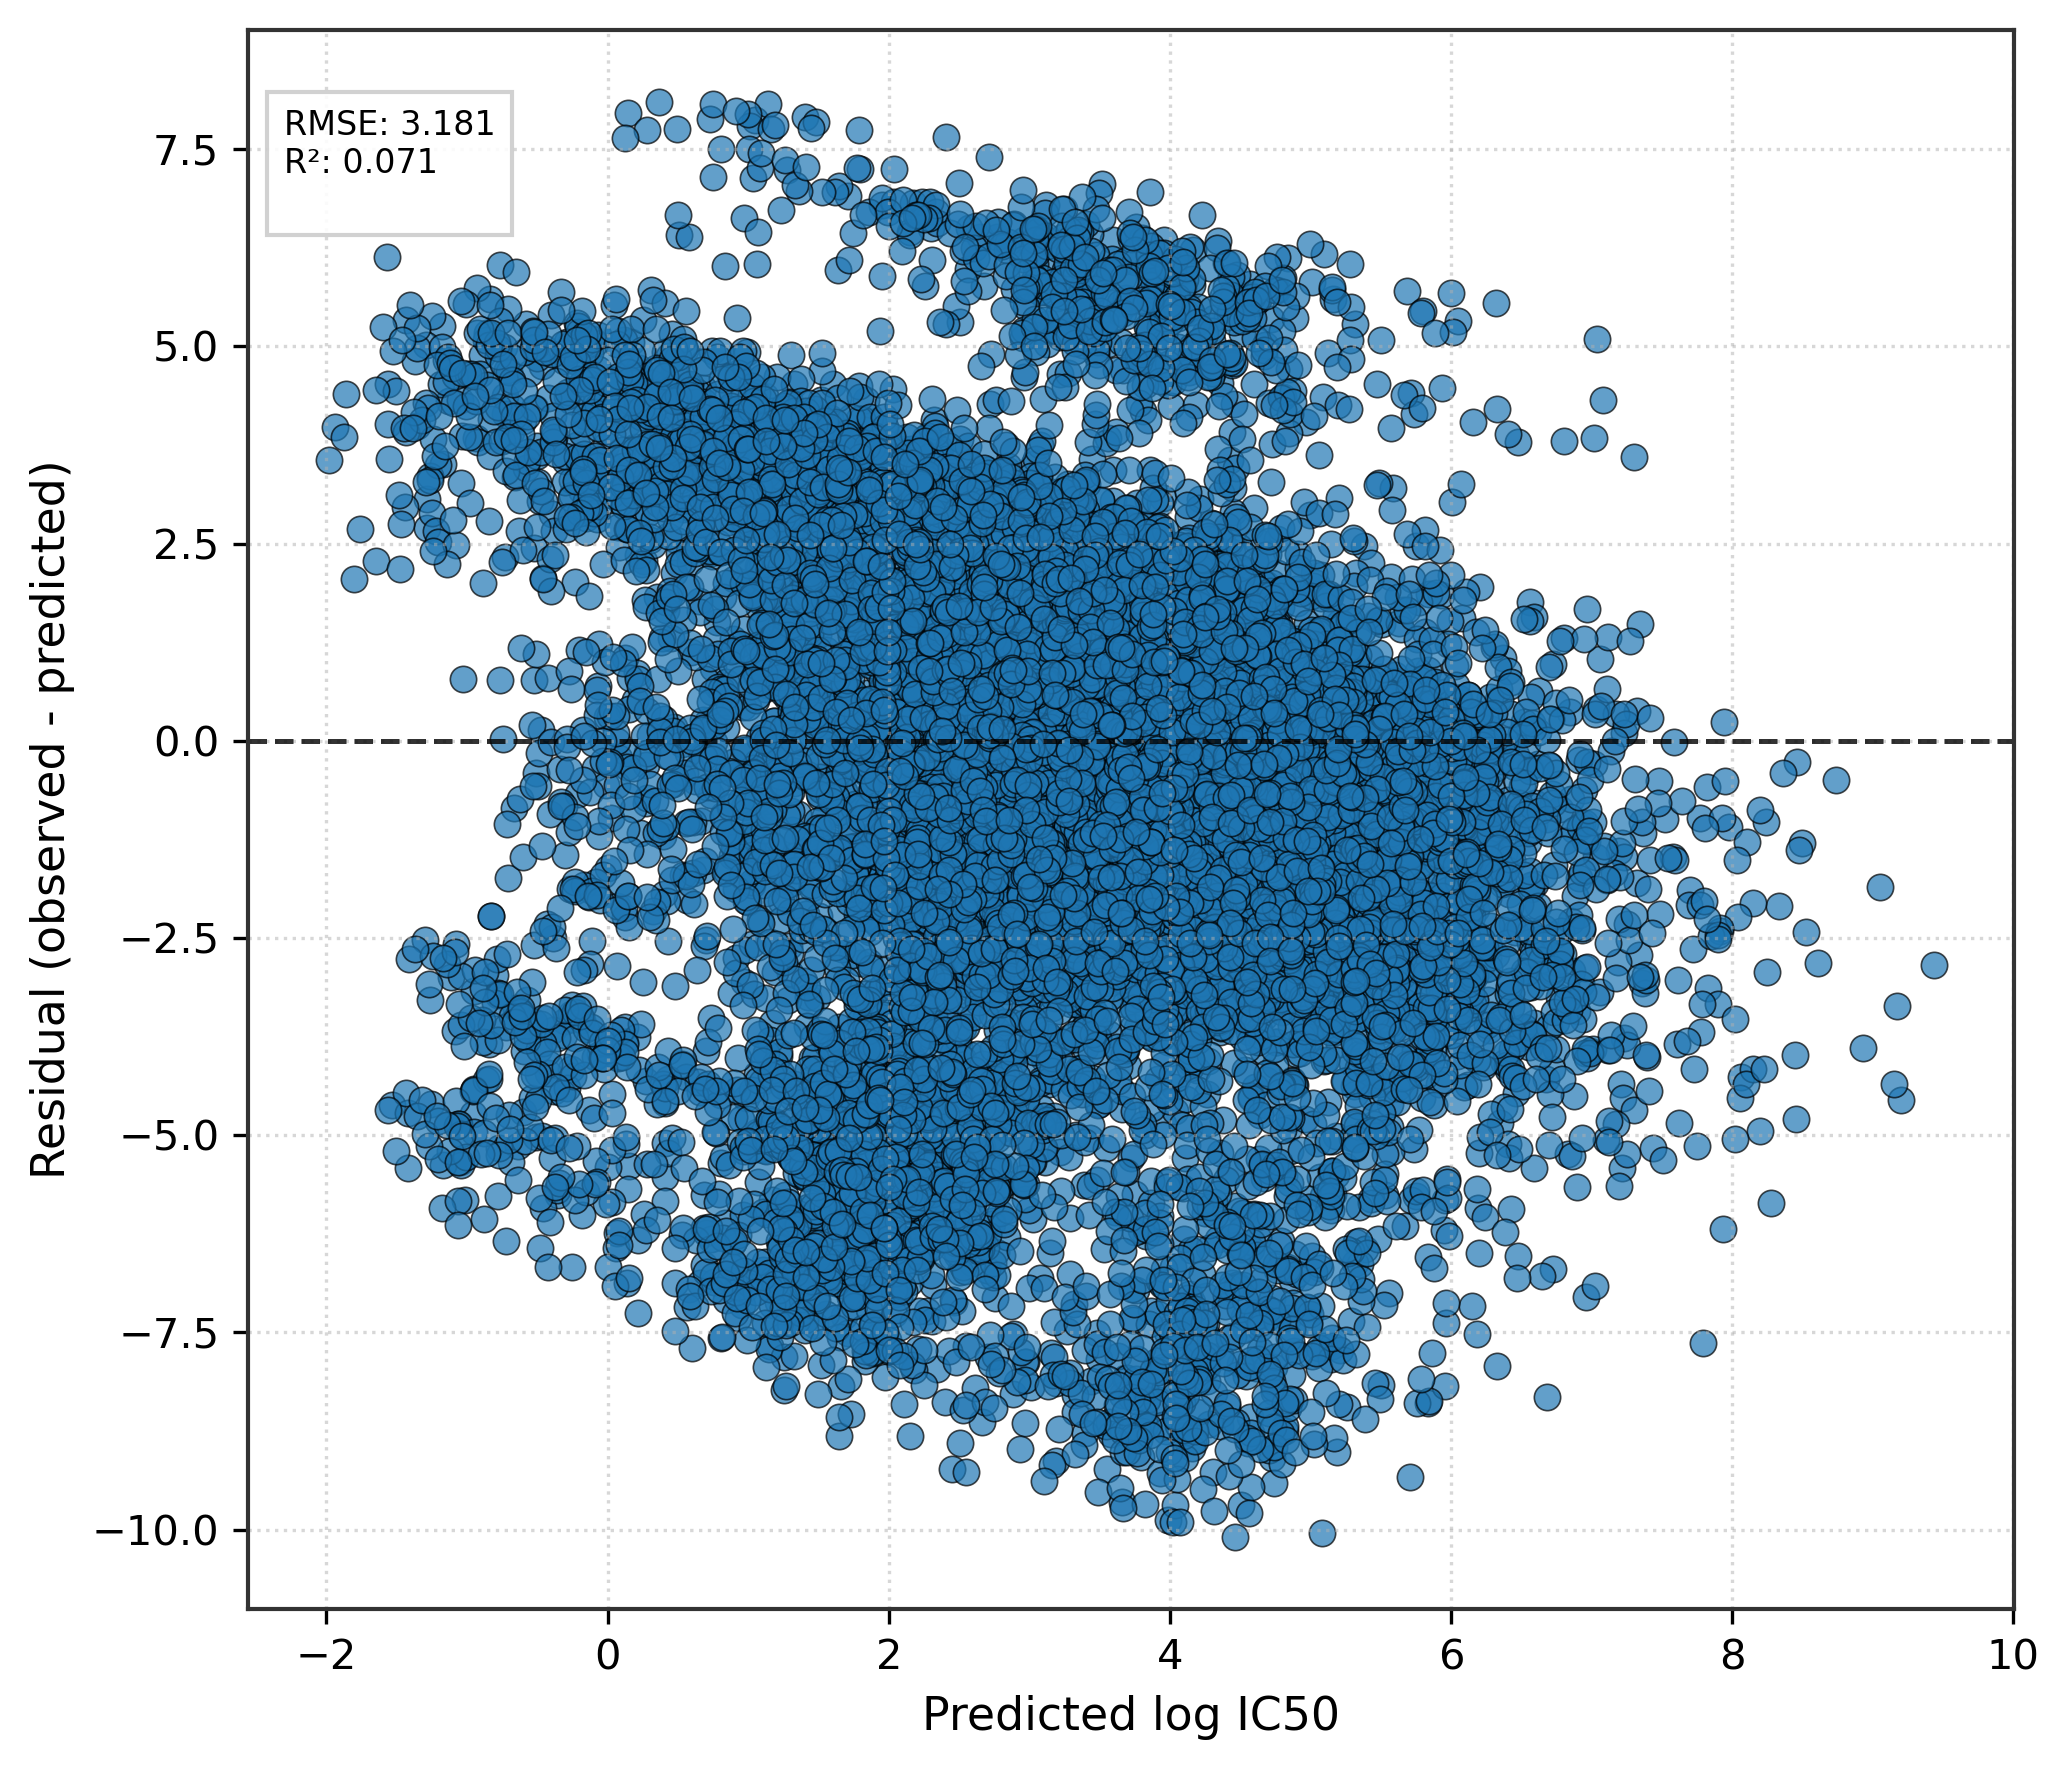

In [112]:
residuals = y_true - y_pred
rmse_val = root_mean_squared_error(y_true, y_pred)
r2_val = r2_score(y_true, y_pred)

fig, ax = plt.subplots(figsize=(7, 6), dpi=300)
ax.scatter(y_pred, residuals, color='#1f77b4', alpha=0.7, s=40, edgecolors='black', linewidth=0.4)
ax.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.8)

ax.set_xlabel("Predicted log IC50", fontsize=11)
ax.set_ylabel("Residual (observed - predicted)", fontsize=11)
ax.grid(True, linestyle=':', alpha=0.5)

info_text = (
    f"RMSE: {rmse_val:.3f}\n"
    f"R²: {r2_val:.3f}\n"
)
ax.text(0.02, 0.95, info_text, transform=ax.transAxes, fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='square,pad=0.5', facecolor='white', alpha=0.9, edgecolor='#cccccc'))

plt.tight_layout()
plt.savefig("residuals_vs_predicted.png", dpi=250, bbox_inches='tight')
plt.show()

## Grid Search

In [46]:
# Grid search cell for CrossAttentionFusionModel
import itertools
import copy
import time
import random

# grid (tune as desired)
param_grid = {
    "hidden_dim": [32, 64],
    "dropout": [0.3, 0.4],
    "num_tokens": [4, 8],
    "num_heads": [4],
    "optimizer": ["adam", "adamw", "sgd"],
    "lr": [1e-3, 5e-4],
    "weight_decay": [1e-2, 1e-3],
}

# settings for grid search training
grid_epochs = 20
early_stopping_patience = 4
seed = 42


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)


set_seed(seed)

# use existing variables if present
_device = device if "device" in globals() else torch.device("cuda" if torch.cuda.is_available() else "cpu")
_gene_dim = X_genomic.shape[1]
_chem_dim = X_chem_train.shape[1]

combos = list(itertools.product(*param_grid.values()))
keys = list(param_grid.keys())

best_overall = {"val_r2": -float("inf"), "val_rmse": float("inf"), "params": None, "state_dict": None}
total = len(combos)
start_time = time.time()

for idx, combo in enumerate(combos, 1):
    params = dict(zip(keys, combo))
    set_seed(seed)
    train_loader, val_loader, test_loader = make_loaders(batch_size=128, seed=seed)

    model = CrossAttentionFusionModel(
        gene_dim=_gene_dim,
        chem_dim=_chem_dim,
        hidden_dim=params["hidden_dim"],
        num_tokens=params["num_tokens"],
        num_heads=params["num_heads"],
        dropout=params["dropout"],
    ).to(_device)

    criterion = nn.MSELoss()
    opt_name = params["optimizer"].lower()
    if opt_name == "adam":
        optimzer = optim.Adam(model.parameters(), lr=params["lr"], weight_decay=params["weight_decay"])
    elif opt_name == "adamw":
        optimzer = optim.AdamW(model.parameters(), lr=params["lr"], weight_decay=params["weight_decay"])
    elif opt_name == "sgd":
        optimzer = optim.SGD(model.parameters(), lr=params["lr"], momentum=0.9, weight_decay=params["weight_decay"])
    else:
        raise ValueError(f"Unknown optimizer {opt_name}")

    best_run_val = float("inf")
    best_run_r2 = -float("inf")
    run_no_improve = 0

    for ep in range(grid_epochs):
        model.train()
        for b_gen, b_chem, b_y in train_loader:
            b_gen = b_gen.to(_device)
            b_chem = b_chem.to(_device)
            b_y = b_y.to(_device).view(-1)

            optimzer.zero_grad()
            preds = model(b_gen, b_chem).view(-1)
            loss = criterion(preds, b_y)
            loss.backward()
            optimzer.step()

        model.eval()
        val_preds_list, val_targets_list = [], []
        with torch.no_grad():
            for b_gen, b_chem, b_y in val_loader:
                b_gen = b_gen.to(_device)
                b_chem = b_chem.to(_device)
                preds = model(b_gen, b_chem).view(-1).cpu().numpy()
                val_preds_list.append(preds)
                val_targets_list.append(b_y.numpy())
        val_preds = np.concatenate(val_preds_list)
        val_targets = np.concatenate(val_targets_list)
        val_rmse = root_mean_squared_error(val_targets, val_preds)
        val_r2 = r2_score(val_targets, val_preds)
        if (val_r2 > best_run_r2 + 1e-6) or (
            abs(val_r2 - best_run_r2) <= 1e-6 and val_rmse < best_run_val - 1e-6
        ):
            best_run_val = val_rmse
            best_run_r2 = val_r2
            run_no_improve = 0
            best_run_state = copy.deepcopy(model.state_dict())
        else:
            run_no_improve += 1
            if run_no_improve >= early_stopping_patience:
                break

    if (best_run_r2 > best_overall["val_r2"] + 1e-6) or (
        abs(best_run_r2 - best_overall["val_r2"]) <= 1e-6 and best_run_val < best_overall["val_rmse"] - 1e-6
    ):
        best_overall["val_r2"] = best_run_r2
        best_overall["val_rmse"] = best_run_val
        best_overall["params"] = params
        best_overall["state_dict"] = best_run_state

    elapsed = time.time() - start_time
    print(f"[{idx}/{total}] params={params} -> val_rmse={best_run_val:.4f} | val_r2={best_run_r2:.4f} | best_so_far={best_overall['val_rmse']:.4f} | elapsed={elapsed:.0f}s")

if best_overall["state_dict"] is not None:
    best_model = CrossAttentionFusionModel(
        gene_dim=_gene_dim,
        chem_dim=_chem_dim,
        hidden_dim=best_overall["params"]["hidden_dim"],
        num_tokens=best_overall["params"]["num_tokens"],
        num_heads=best_overall["params"]["num_heads"],
        dropout=best_overall["params"]["dropout"],
    ).to(_device)
    best_model.load_state_dict(best_overall["state_dict"])
    torch.save(best_model.state_dict(), "best_grid_model.pt")

print("GRID SEARCH DONE")
print("Best val_rmse:", best_overall["val_rmse"])
print("Best val_r2:", best_overall["val_r2"])
print("Best params:", best_overall["params"])

if best_overall["state_dict"] is not None:
    best_model.eval()
    val_preds_list, val_targets_list = [], []
    with torch.no_grad():
        for b_gen, b_chem, b_y in val_loader:
            b_gen = b_gen.to(_device)
            b_chem = b_chem.to(_device)
            preds = best_model(b_gen, b_chem).view(-1).cpu().numpy()
            val_preds_list.append(preds)
            val_targets_list.append(b_y.numpy())
    val_preds = np.concatenate(val_preds_list)
    val_targets = np.concatenate(val_targets_list)
    ss_res = np.sum((val_targets - val_preds) ** 2)
    ss_tot = np.sum((val_targets - np.mean(val_targets)) ** 2)
    best_val_r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")
    print("Best val_r2:", best_val_r2)
else:
    print("No best model found to evaluate r2.")

[1/96] params={'hidden_dim': 32, 'dropout': 0.3, 'num_tokens': 4, 'num_heads': 4, 'optimizer': 'adam', 'lr': 0.001, 'weight_decay': 0.01} -> val_rmse=2.3605 | best_so_far=2.3605 | elapsed=247s
[2/96] params={'hidden_dim': 32, 'dropout': 0.3, 'num_tokens': 4, 'num_heads': 4, 'optimizer': 'adam', 'lr': 0.001, 'weight_decay': 0.001} -> val_rmse=2.4218 | best_so_far=2.3605 | elapsed=481s
[3/96] params={'hidden_dim': 32, 'dropout': 0.3, 'num_tokens': 4, 'num_heads': 4, 'optimizer': 'adam', 'lr': 0.0005, 'weight_decay': 0.01} -> val_rmse=2.4670 | best_so_far=2.3605 | elapsed=707s
[4/96] params={'hidden_dim': 32, 'dropout': 0.3, 'num_tokens': 4, 'num_heads': 4, 'optimizer': 'adam', 'lr': 0.0005, 'weight_decay': 0.001} -> val_rmse=2.5805 | best_so_far=2.3605 | elapsed=826s
[5/96] params={'hidden_dim': 32, 'dropout': 0.3, 'num_tokens': 4, 'num_heads': 4, 'optimizer': 'adamw', 'lr': 0.001, 'weight_decay': 0.01} -> val_rmse=2.4048 | best_so_far=2.3605 | elapsed=1046s
[6/96] params={'hidden_dim': 

## Analysis of attention weights

ok wow, man sieht gar nichts. Attention weigths sind sehr gleichmäßig verteilt (5 tokens jeweils 20%)


Look at distribution of tokens and the heatmap of cross-attention

Gene→Drug attention shape: (14648, 5, 5)
Drug→Gene attention shape: (14648, 5, 5)

Averaged Gene→Drug attention:
[[0.19997096 0.19997822 0.19997081 0.19997047 0.19997182]
 [0.19997092 0.1999799  0.1999703  0.19997063 0.19997296]
 [0.1999706  0.19997774 0.19997045 0.19997112 0.19997302]
 [0.19997035 0.19997835 0.19997017 0.19997057 0.19997324]
 [0.1999705  0.19997872 0.1999703  0.19997056 0.19997238]]

Averaged Drug→Gene attention:
[[0.19997115 0.1999725  0.19997099 0.19997105 0.19997132]
 [0.19997254 0.19997495 0.19997141 0.19997154 0.19997177]
 [0.19997118 0.19997309 0.19997096 0.19997098 0.1999721 ]
 [0.19997175 0.19997583 0.19997111 0.19997111 0.19997266]
 [0.19997251 0.19997855 0.19997092 0.19997124 0.19997314]]


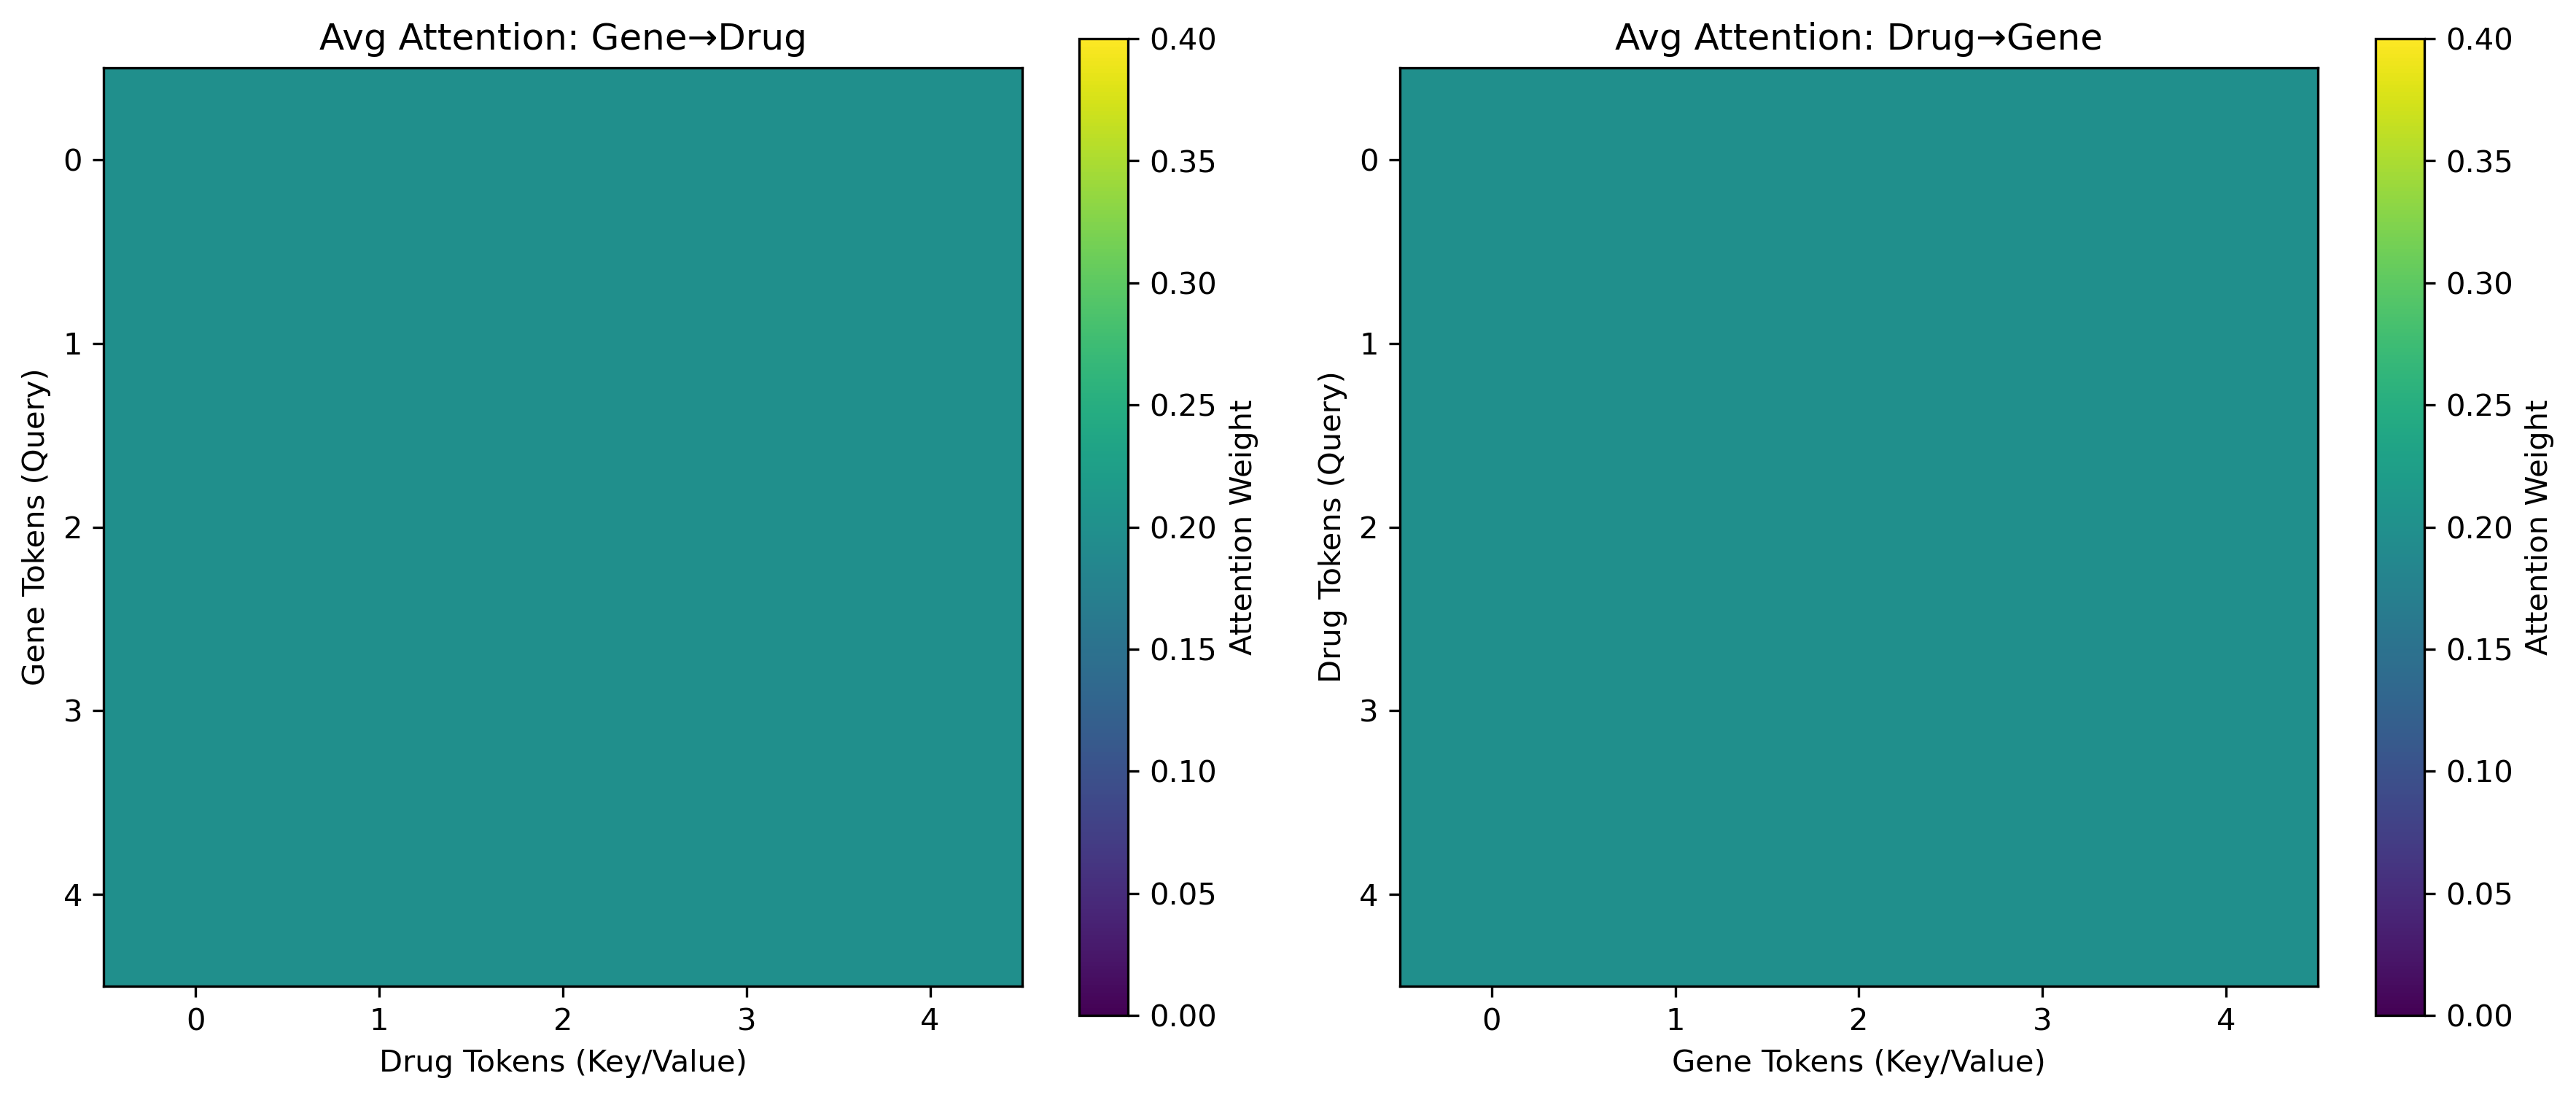


Attention Analysis Complete!


In [50]:
# Load the best model and analyze attention weights
best_model_path = "bestes_Modell_mit_7prozentoderso.pt"  # or "bestes_Modell_mit_7prozentoderso.pt" if available
hidden_dim = 32
dropout = 0.5
lr = 1e-3
patience = 6
epochs = 24
weight_decay = 1e-2
num_tokens = 5

#set_seed(6726)
train_loader, val_loader, test_loader = make_loaders(batch_size=128, seed=6726)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Recreate the model with best parameters from grid search
best_model = CrossAttentionFusionModel(
    gene_dim=X_genomic.shape[1],
    chem_dim=X_chem_train.shape[1],
    hidden_dim=hidden_dim,
    num_tokens=num_tokens,
    num_heads=4,
    dropout=dropout,
).to(device)
best_model.load_state_dict(torch.load(best_model_path, weights_only=True))
best_model.eval()

# Collect attention weights on test set
all_gene_attn_weights = []
all_drug_attn_weights = []

with torch.no_grad():
    for batch_genes, batch_chem, batch_y in test_loader:
        batch_genes = batch_genes.to(device)
        batch_chem = batch_chem.to(device)
        _ = best_model(batch_genes, batch_chem)
        
        # Extract attention weights stored in model
        all_gene_attn_weights.append(best_model.last_attn_weights["gene_to_drug"])
        all_drug_attn_weights.append(best_model.last_attn_weights["drug_to_gene"])

# Stack all batches: shape (num_batches, batch_size, num_heads, num_tokens, num_tokens)
gene_attn_stacked = np.concatenate(all_gene_attn_weights, axis=0)
drug_attn_stacked = np.concatenate(all_drug_attn_weights, axis=0)

print(f"Gene→Drug attention shape: {gene_attn_stacked.shape}")
print(f"Drug→Gene attention shape: {drug_attn_stacked.shape}")

# Average attention weights across batches and heads for visualization
gene_attn_avg = gene_attn_stacked.mean(axis=0)  # Average over batches and heads
drug_attn_avg = drug_attn_stacked.mean(axis=0)

print(f"\nAveraged Gene→Drug attention:\n{gene_attn_avg}")
print(f"\nAveraged Drug→Gene attention:\n{drug_attn_avg}")

# Visualize attention patterns
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=300)

# Gene to Drug attention heatmap
im1 = axes[0].imshow(gene_attn_avg, cmap='viridis', aspect='equal', vmin=0.0, vmax=0.4)
axes[0].set_xlabel('Drug Tokens (Key/Value)', fontsize=10)
axes[0].set_ylabel('Gene Tokens (Query)', fontsize=10)
plt.colorbar(im1, ax=axes[0], label='Attention Weight')

# Drug to Gene attention heatmap
im2 = axes[1].imshow(drug_attn_avg, cmap='viridis', aspect='equal', vmin=0.0, vmax=0.4)
axes[0].set_title('Avg Attention: Gene→Drug', fontsize=12)
axes[1].set_title('Avg Attention: Drug→Gene', fontsize=12)
axes[1].set_xlabel('Gene Tokens (Key/Value)', fontsize=10)
axes[1].set_ylabel('Drug Tokens (Query)', fontsize=10)
plt.colorbar(im2, ax=axes[1], label='Attention Weight')

plt.tight_layout()
plt.savefig("attention_weights_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

print("\nAttention Analysis Complete!")

Inspect which original input features contribute most to each latent token.
This gives an interpretable proxy for "which features landed in each token"

Top contributing genomic features per gene token:

Gene token 0:
  - H2AZ2 (94239): 0.0221
  - PIP4K2B (8396): 0.0218
  - UBQLN2 (29978): 0.0211
  - PRKCD (5580): 0.0205
  - CARMIL1 (55604): 0.0203
  - GRB10 (2887): 0.0203
  - NCOA3 (8202): 0.0201
  - ADRB2 (154): 0.0199
  - HPRT1 (3251): 0.0198
  - ELP1 (8518): 0.0196

Gene token 1:
  - RAB11FIP2 (22841): 0.0213
  - CCDC92 (80212): 0.0209
  - UBE3C (9690): 0.0208
  - ZNF318 (24149): 0.0204
  - NT5DC2 (64943): 0.0204
  - CENPE (1062): 0.0201
  - CCDC86 (79080): 0.0200
  - STMN1 (3925): 0.0198
  - PPP2R5A (5525): 0.0198
  - ATP2C1 (27032): 0.0197

Gene token 2:
  - GADD45A (1647): 0.0205
  - STMN1 (3925): 0.0201
  - YTHDF1 (54915): 0.0201
  - RGS2 (5997): 0.0200
  - BID (637): 0.0199
  - PCNA (5111): 0.0198
  - BRCA1 (672): 0.0198
  - PARP2 (10038): 0.0197
  - AMDHD2 (51005): 0.0197
  - OXCT1 (5019): 0.0197

Gene token 3:
  - GLI2 (2736): 0.0213
  - ELOVL6 (79071): 0.0212
  - STK10 (6793): 0.0210
  - CLPX (10845): 0.0210
  - MEF2C (4208

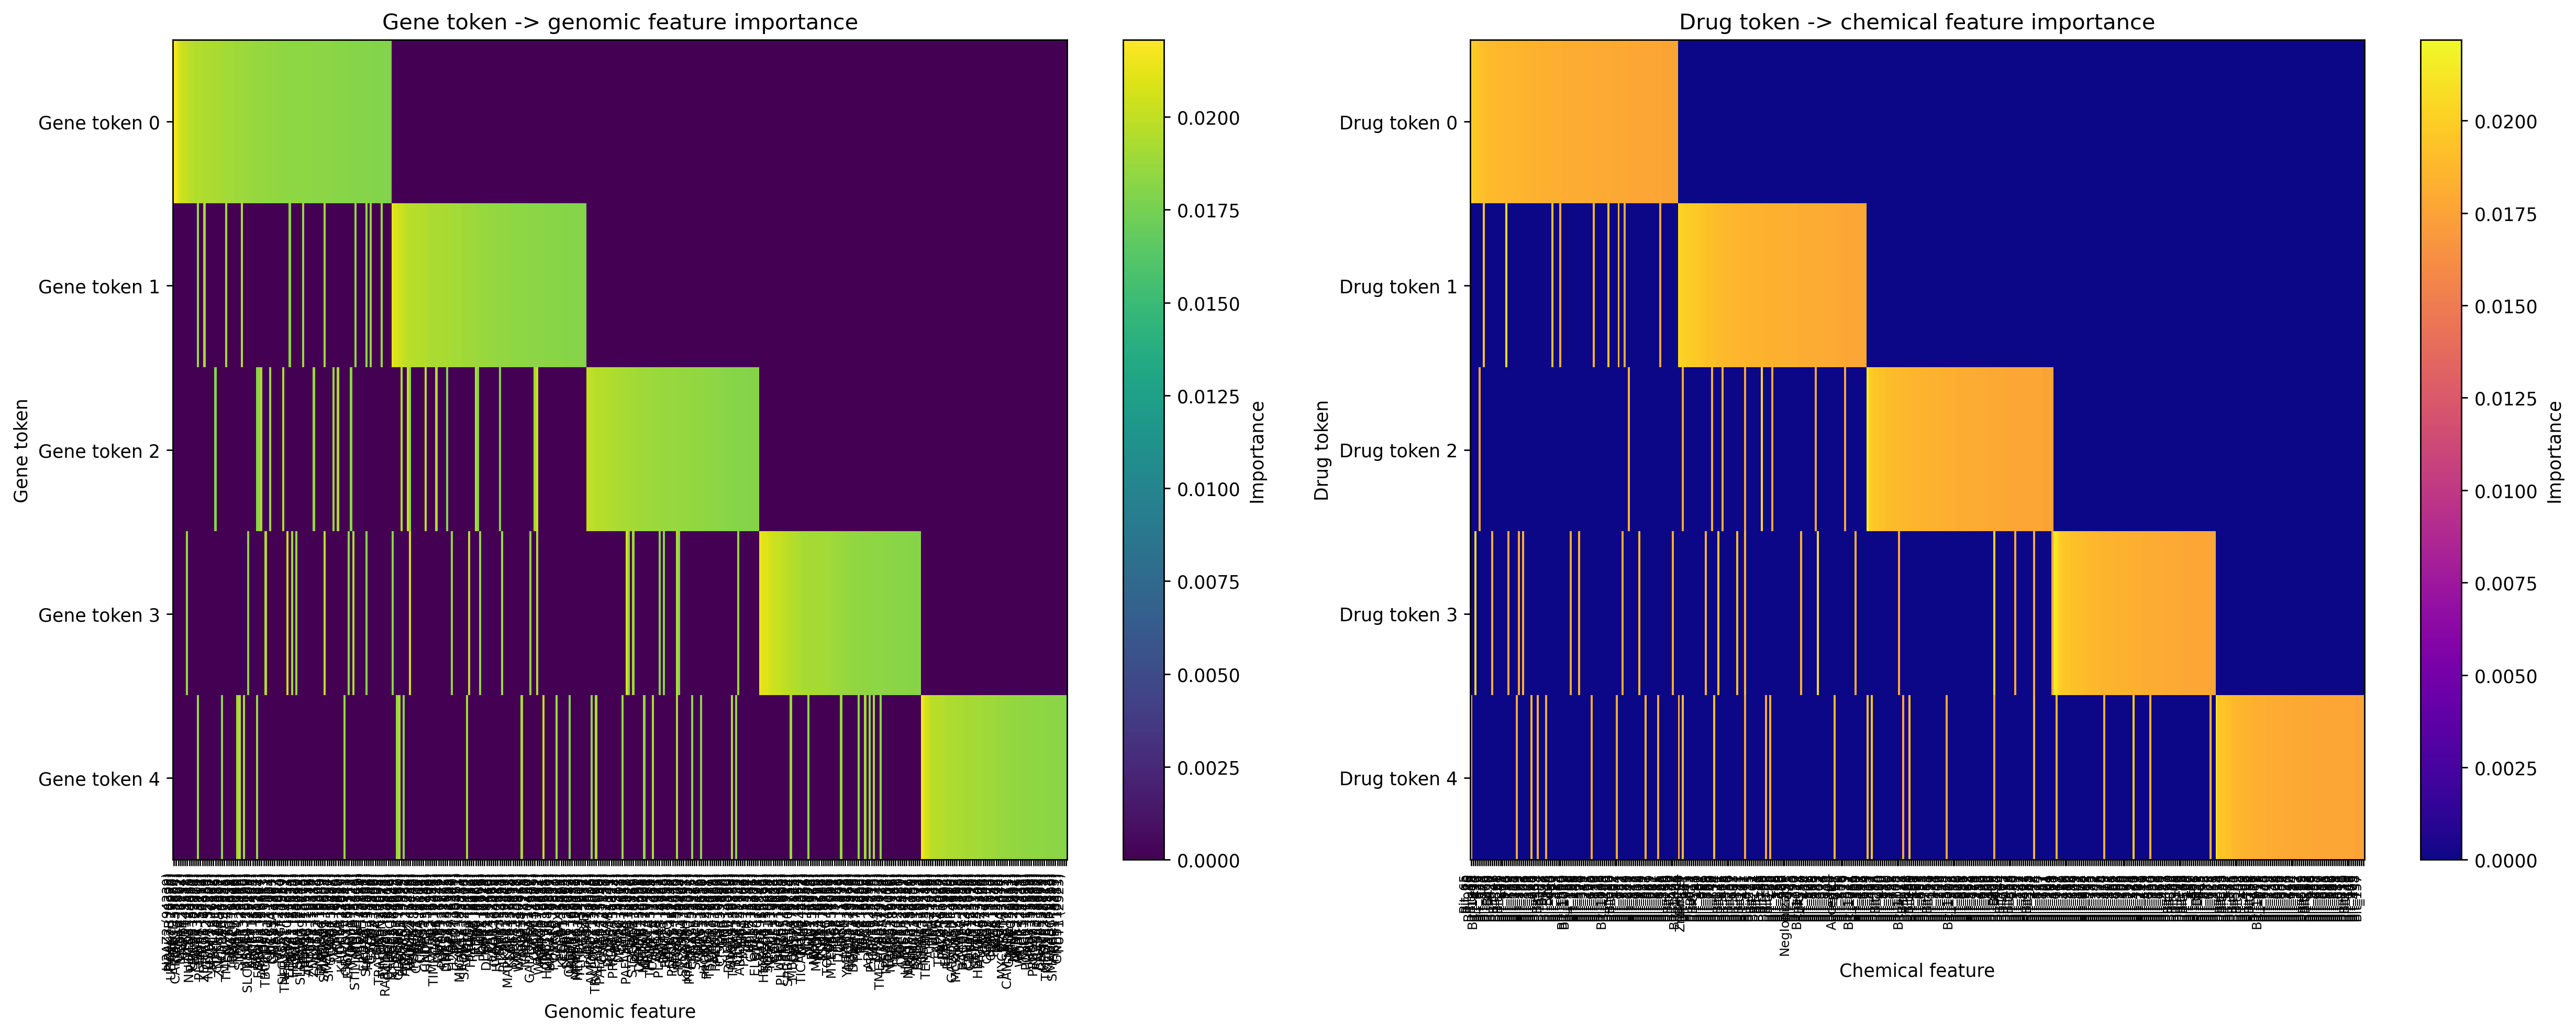

In [164]:
if "model" not in globals():
    raise RuntimeError("The model has not been created yet. Run the training cell first.")

if not hasattr(model, "gene_encoder") or not hasattr(model, "drug_encoder"):
    raise RuntimeError("The current model does not expose gene/drug encoders in the expected way.")
model = best_model
# First linear projection layers
gene_proj = model.gene_encoder[0]
drug_proj = model.drug_encoder[0]

gene_weights = gene_proj.weight.detach().cpu().numpy()   # shape: [num_tokens * hidden_dim, gene_dim]
drug_weights = drug_proj.weight.detach().cpu().numpy()   # shape: [num_tokens * hidden_dim, chem_dim]

# Reshape to [num_tokens, hidden_dim, feature_dim]
gene_weights_tokens = gene_weights.reshape(model.num_tokens, model.hidden_dim, -1)
drug_weights_tokens = drug_weights.reshape(model.num_tokens, model.hidden_dim, -1)

# Aggregate contribution across hidden-dim subchannels for each token
# Using mean absolute weight as a simple importance score
gene_token_importance = np.abs(gene_weights_tokens).mean(axis=1)   # [num_tokens, gene_dim]
drug_token_importance = np.abs(drug_weights_tokens).mean(axis=1)   # [num_tokens, chem_dim]

# Feature names
if "gene_feature_names" not in globals():
    gene_feature_names = df.filter(regex=r'.* \(.*\)').columns.tolist()

if "chem_feature_names" not in globals():
    chem_feature_names = X_chem.columns.tolist()

# Print top features per token
print("Top contributing genomic features per gene token:\n")
for token_idx in range(model.num_tokens):
    top_idx = np.argsort(gene_token_importance[token_idx])[::-1][:10]
    print(f"Gene token {token_idx}:")
    for feat_idx in top_idx:
        print(f"  - {gene_feature_names[feat_idx]}: {gene_token_importance[token_idx, feat_idx]:.4f}")
    print()

print("Top contributing chemical features per drug token:\n")
for token_idx in range(model.num_tokens):
    top_idx = np.argsort(drug_token_importance[token_idx])[::-1][:10]
    print(f"Drug token {token_idx}:")
    for feat_idx in top_idx:
        print(f"  - {chem_feature_names[feat_idx]}: {drug_token_importance[token_idx, feat_idx]:.4f}")
    print()

# Heatmaps of token-feature importance
# Use a manageable number of features and show their names on the x-axis
n_top_features = 100

# Gene heatmap: select the top features for each token and create a matrix
all_gene_feature_names = []
all_gene_scores = []
for token_idx in range(model.num_tokens):
    top_idx = np.argsort(gene_token_importance[token_idx])[::-1][:n_top_features]
    all_gene_scores.append(gene_token_importance[token_idx, top_idx])
    all_gene_feature_names.append([gene_feature_names[i] for i in top_idx])

# Create a shared feature list for the x-axis by taking the union of the top features across tokens
shared_gene_features = []
for names in all_gene_feature_names:
    shared_gene_features.extend(names)
shared_gene_features = list(dict.fromkeys(shared_gene_features))

# Build a matrix with rows=tokens and columns=shared features, filling missing values with 0
shared_gene_feature_index = {name: idx for idx, name in enumerate(shared_gene_features)}
gene_heatmap_matrix = np.zeros((model.num_tokens, len(shared_gene_features)), dtype=float)
for token_idx, names in enumerate(all_gene_feature_names):
    for name in names:
        gene_heatmap_matrix[token_idx, shared_gene_feature_index[name]] = gene_token_importance[token_idx, gene_feature_names.index(name)]

fig, axes = plt.subplots(1, 2, figsize=(20, 8), dpi=250)

im1 = axes[0].imshow(gene_heatmap_matrix, aspect='auto', cmap='viridis')
axes[0].set_title('Gene token -> genomic feature importance')
axes[0].set_xlabel('Genomic feature')
axes[0].set_ylabel('Gene token')
axes[0].set_yticks(range(model.num_tokens))
axes[0].set_yticklabels([f'Gene token {i}' for i in range(model.num_tokens)])
axes[0].set_xticks(range(len(shared_gene_features)))
axes[0].set_xticklabels(shared_gene_features, rotation=90, ha='right', fontsize=7)
plt.colorbar(im1, ax=axes[0], label='Importance')

# Drug heatmap
all_drug_feature_names = []
all_drug_scores = []
for token_idx in range(model.num_tokens):
    top_idx = np.argsort(drug_token_importance[token_idx])[::-1][:n_top_features]
    all_drug_scores.append(drug_token_importance[token_idx, top_idx])
    all_drug_feature_names.append([chem_feature_names[i] for i in top_idx])

shared_drug_features = []
for names in all_drug_feature_names:
    shared_drug_features.extend(names)
shared_drug_features = list(dict.fromkeys(shared_drug_features))

shared_drug_feature_index = {name: idx for idx, name in enumerate(shared_drug_features)}
drug_heatmap_matrix = np.zeros((model.num_tokens, len(shared_drug_features)), dtype=float)
for token_idx, names in enumerate(all_drug_feature_names):
    for name in names:
        drug_heatmap_matrix[token_idx, shared_drug_feature_index[name]] = drug_token_importance[token_idx, chem_feature_names.index(name)]

im2 = axes[1].imshow(drug_heatmap_matrix, aspect='auto', cmap='plasma')
axes[1].set_title('Drug token -> chemical feature importance')
axes[1].set_xlabel('Chemical feature')
axes[1].set_ylabel('Drug token')
axes[1].set_yticks(range(model.num_tokens))
axes[1].set_yticklabels([f'Drug token {i}' for i in range(model.num_tokens)])
axes[1].set_xticks(range(len(shared_drug_features)))
axes[1].set_xticklabels(shared_drug_features, rotation=90, ha='right', fontsize=7)
plt.colorbar(im2, ax=axes[1], label='Importance')

plt.tight_layout()
plt.show()

Compare gene token representation with respect to grouped cancer type. Plot reveals no outliers

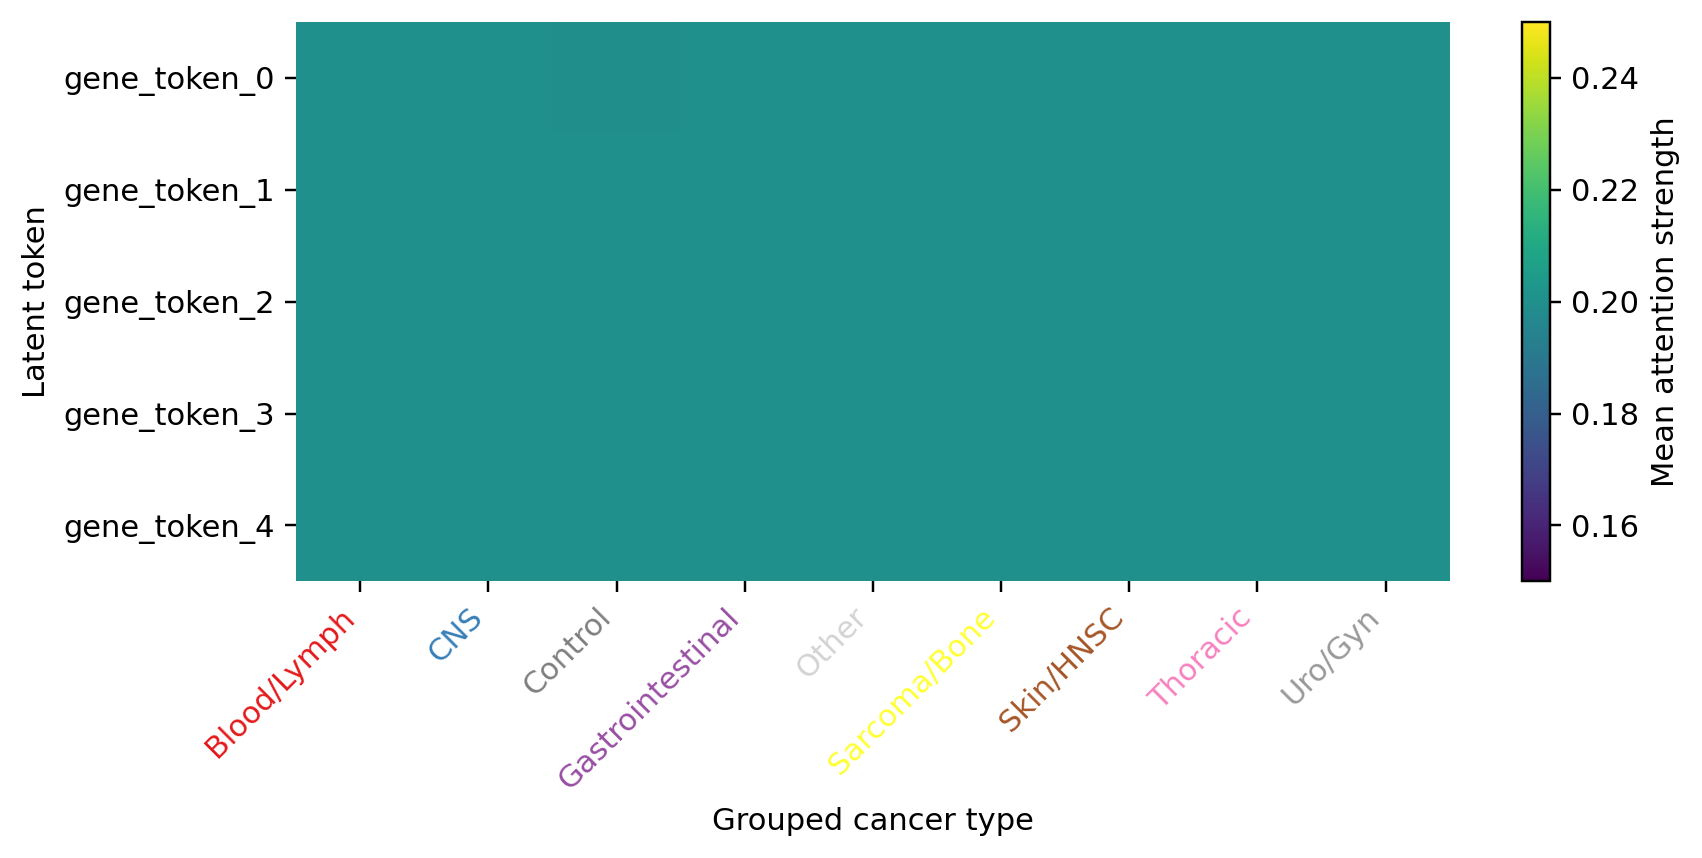


Top attention tokens per grouped cancer category:

META_CANCERTYPE=Blood/Lymph
       token  attention_strength
gene_token_1                 0.2
gene_token_3                 0.2
gene_token_0                 0.2

META_CANCERTYPE=CNS
       token  attention_strength
gene_token_4                 0.2
gene_token_3                 0.2
gene_token_0                 0.2

META_CANCERTYPE=Control
       token  attention_strength
gene_token_1                 0.2
gene_token_4                 0.2
gene_token_2                 0.2

META_CANCERTYPE=Gastrointestinal
       token  attention_strength
gene_token_4                 0.2
gene_token_2                 0.2
gene_token_1                 0.2

META_CANCERTYPE=Other
       token  attention_strength
gene_token_0                 0.2
gene_token_3                 0.2
gene_token_1                 0.2

META_CANCERTYPE=Sarcoma/Bone
       token  attention_strength
gene_token_3                 0.2
gene_token_1                 0.2
gene_token_4                

In [73]:
# Connect attention weights to biological metadata from df
# This is useful for a biological analysis paragraph about which tumor contexts the model focuses on.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if "model" not in globals():
    raise RuntimeError("Create and train the model first.")
if "test_loader" not in globals():
    raise RuntimeError("Create the test_loader first.")
if "df" not in globals():
    raise RuntimeError("Load df first.")

# Force the grouping column to be CANCER_TYPE
group_col = "CANCER_TYPE"
if group_col not in df.columns:
    raise RuntimeError(f"Column {group_col} is not present in df.")

category_map = {
    # Hematologic (Blood & Lymph)
    'T-Lymphoblastic Leukemia': 'Blood/Lymph',
    'Acute Myeloid Leukemia': 'Blood/Lymph',
    'Chronic Myelogenous Leukemia': 'Blood/Lymph',
    'B-Lymphoblastic Leukemia': 'Blood/Lymph',
    'Plasma Cell Myeloma': 'Blood/Lymph',
    "T-Cell Non-Hodgkin's Lymphoma": 'Blood/Lymph',
    "B-Cell Non-Hodgkin's Lymphoma": 'Blood/Lymph',
    "Burkitt's Lymphoma": 'Blood/Lymph',
    "Hodgkin's Lymphoma": 'Blood/Lymph',
    'Other Blood Cancers': 'Blood/Lymph',

    # Gastrointestinal (GI Tract)
    'Colorectal Carcinoma': 'Gastrointestinal',
    'Gastric Carcinoma': 'Gastrointestinal',
    'Pancreatic Carcinoma': 'Gastrointestinal',
    'Hepatocellular Carcinoma': 'Gastrointestinal',
    'Biliary Tract Carcinoma': 'Gastrointestinal',
    'Esophageal Carcinoma': 'Gastrointestinal',
    'Esophageal Squamous Cell Carcinoma': 'Gastrointestinal',

    # Thoracic (Lung & Chest)
    'Non-Small Cell Lung Carcinoma': 'Thoracic',
    'Squamous Cell Lung Carcinoma': 'Thoracic',
    'Small Cell Lung Carcinoma': 'Thoracic',
    'Mesothelioma': 'Thoracic',

    # Sarcomas (Bone & Soft Tissue)
    "Ewing's Sarcoma": 'Sarcoma/Bone',
    'Osteosarcoma': 'Sarcoma/Bone',
    'Chondrosarcoma': 'Sarcoma/Bone',
    'Rhabdomyosarcoma': 'Sarcoma/Bone',
    'Other Sarcomas': 'Sarcoma/Bone',

    # CNS (Brain)
    'Glioblastoma': 'CNS',
    'Glioma': 'CNS',
    'Neuroblastoma': 'CNS',

    # Gynecologic / Urologic
    'Ovarian Carcinoma': 'Uro/Gyn',
    'Cervical Carcinoma': 'Uro/Gyn',
    'Endometrial Carcinoma': 'Uro/Gyn',
    'Breast Carcinoma': 'Uro/Gyn',
    'Prostate Carcinoma': 'Uro/Gyn',
    'Bladder Carcinoma': 'Uro/Gyn',
    'Kidney Carcinoma': 'Uro/Gyn',

    # Head & Neck / Skin / Endocrine
    'Melanoma': 'Skin/HNSC',
    'Head and Neck Carcinoma': 'Skin/HNSC',
    'Oral Cavity Carcinoma': 'Skin/HNSC',
    'Thyroid Gland Carcinoma': 'Skin/HNSC',

    # Others
    'Non-Cancerous': 'Control',
    'Other Solid Cancers': 'Other'
}

# Apply the mapping to the dataframe
df = df.copy()
df["META_CANCERTYPE"] = df[group_col].map(category_map).fillna("Other")

# Use original test indices if available; otherwise fall back to the dataframe index.
if "idx_test" in globals():
    sample_indices = idx_test
else:
    sample_indices = df.index.to_numpy()

rows = []
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.eval()
with torch.no_grad():
    batch_start = 0
    for batch_genes, batch_chem, batch_y in test_loader:
        batch_size = batch_genes.size(0)
        batch_genes = batch_genes.to(device)
        batch_chem = batch_chem.to(device)
        _ = model(batch_genes, batch_chem)

        attn = model.last_attn_weights["gene_to_drug"]
        attn_mean = attn#.mean(axis=1)  # average over heads
        token_strength = attn_mean.mean(axis=-1)  # per sample, per query token

        batch_indices = sample_indices[batch_start:batch_start + batch_size]
        batch_start += batch_size

        batch_meta = df.loc[batch_indices].copy()
        for sample_pos in range(batch_size):
            sample_meta = batch_meta.iloc[sample_pos]
            for token_idx in range(model.num_tokens):
                rows.append({
                    "sample_id": int(batch_indices[sample_pos]),
                    "token": f"gene_token_{token_idx}",
                    "attention_strength": float(token_strength[sample_pos, token_idx]),
                    group_col: sample_meta[group_col],
                    "META_CANCERTYPE": sample_meta["META_CANCERTYPE"],
                })

attn_df = pd.DataFrame(rows)

summary = (
    attn_df.groupby(["META_CANCERTYPE", "token"])["attention_strength"]
    .mean()
    .reset_index()
)
pivot = (
    summary.pivot(index="token", columns="META_CANCERTYPE", values="attention_strength")
    .sort_index(axis=0)
    .sort_index(axis=1)
)

# color palette for grouped cancer categories
unique_categories = sorted(pivot.columns)
base_colors = sns.color_palette("Set1", len(unique_categories))
color_dict = dict(zip(unique_categories, base_colors))
if 'Other' in color_dict:
    color_dict['Other'] = '#d3d3d3'
if 'Control' in color_dict:
    color_dict['Control'] = '#7f7f7f'

fig, ax = plt.subplots(
    figsize=(max(8, 0.9 * len(pivot.columns)), max(4, 0.45 * len(pivot.index))),
    dpi=220,
)
im = ax.imshow(pivot.values, cmap="viridis", aspect="auto", vmin=0.15, vmax=0.25)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha="right")
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
#ax.set_title("Mean attention strength by grouped cancer category")
ax.set_xlabel("Grouped cancer type")
ax.set_ylabel("Latent token")

for label, color in zip(ax.get_xticklabels(), [color_dict[c] for c in pivot.columns]):
    label.set_color(color)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.colorbar(im, ax=ax, label="Mean attention strength")
plt.tight_layout()
plt.show()

print("\nTop attention tokens per grouped cancer category:")
for category in pivot.columns:
    category_rows = summary[summary["META_CANCERTYPE"] == category].sort_values("attention_strength", ascending=False)
    print(f"\nMETA_CANCERTYPE={category}")
    print(category_rows[["token", "attention_strength"]].head(3).to_string(index=False))

## Error analysis

We wanna look a differences in the prediction of IC50 among the drug clusters (truncate mode for better readability, using situation from visualization script).

You can see the problem in the next cell: Many clusters only contain one drug. That leads to bad test results because the cluster can't be split.

Plot 1: Histogram of RMSE per structural cluster (only include these with 5 oder more)

Plot 2: Boxplot of residual distribution of clusters (only these with highest RMSE)

Overall number of clusters: 74
         n_samples  n_drugs      RMSE       MAE         R2
cluster                                                   
56           704.0      1.0  7.239904  7.098753 -10.581882
10           713.0      1.0  5.854673  5.755517 -12.700983
43           572.0      1.0  5.688583  5.608673 -39.453880
8            658.0      1.0  4.481594  4.360353  -8.011197
48           887.0      2.0  3.254395  2.964074  -5.646645
58           713.0      1.0  3.057372  2.863734  -4.630552
49           711.0      1.0  2.672207  2.156901  -1.212055
31           705.0      1.0  2.205721  1.850932  -0.036153
29          2818.0      4.0  2.177074  1.773657  -0.844525
16          1263.0      2.0  1.820539  1.603831   0.023334
57           705.0      1.0  1.817256  1.554690  -0.415579
39           802.0      2.0  1.794079  1.555366  -1.514371
45           704.0      1.0  1.743322  1.401998   0.382854
59           699.0      1.0  1.721459  1.361885   0.277309
21           573.0      1

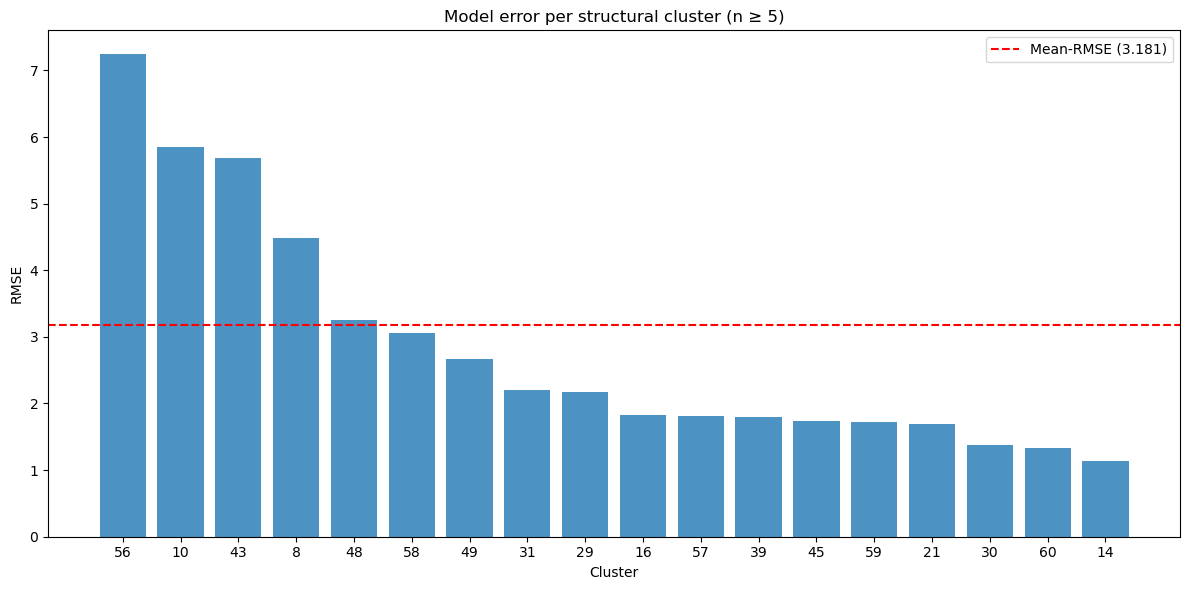

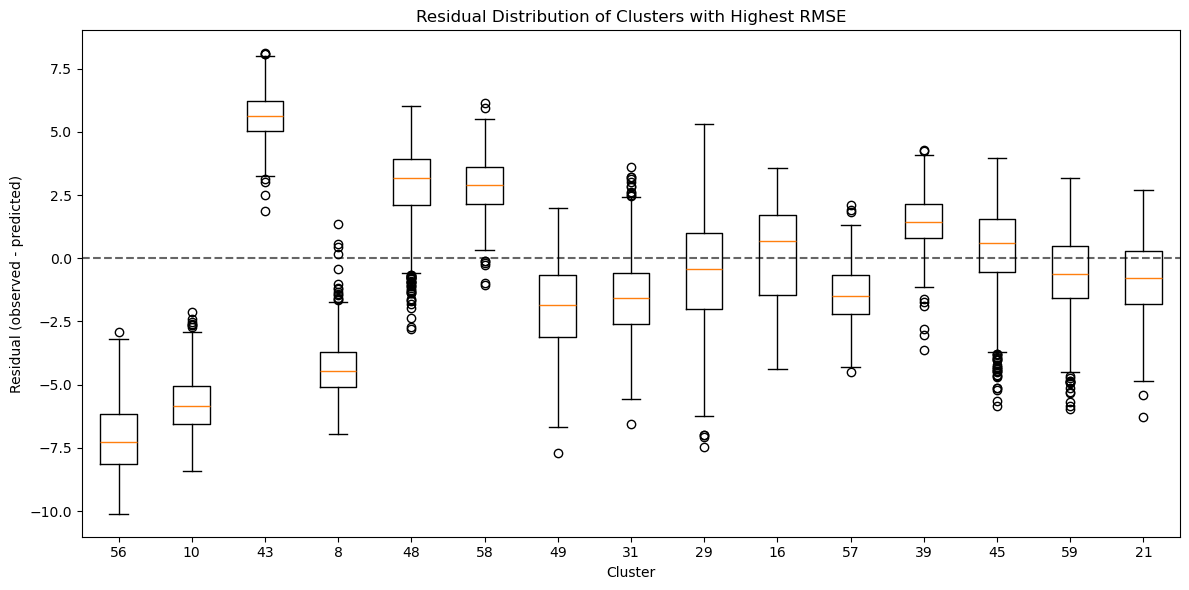


Drugs in cluster with highest RMSE (56):
<StringArray>
['Vinorelbine']
Length: 1, dtype: str


In [150]:
def to_bit_array(fp):
    if hasattr(fp, "ToBitString"):
        return np.array(list(fp.ToBitString()), dtype=int)
    if isinstance(fp, str):
        return np.array(list(fp), dtype=int)
    return np.array(fp, dtype=int)

fp_matrix = np.vstack(df["MorganFP"].apply(to_bit_array).values)
fp_cols = [col for col in df.columns if col.startswith("Bit_")]
pharm_cols = ["Donor", "Acceptor", "Aromatic", "Hydrophobe",
              "LumpedHydrophobe", "PosIonizable", "NegIonizable", "ZnBinder"]

feature_df = df[fp_cols + pharm_cols].copy()
feature_df["DRUG_NAME"] = df["DRUG_NAME"].values

df_unique = feature_df.drop_duplicates(subset=fp_cols + pharm_cols).reset_index(drop=True)

dist_condensed = pdist(df_unique[fp_cols].values, metric="jaccard")
Z = linkage(dist_condensed, method="average")

max_dist = 0.8
df_unique["cluster"] = fcluster(Z, t=max_dist, criterion="distance")

feature_df = feature_df.merge(
    df_unique[fp_cols + pharm_cols + ["cluster"]],
    on=fp_cols + pharm_cols,
    how="left"
)
df["cluster"] = feature_df["cluster"].values
print("Overall number of clusters:", df["cluster"].nunique())

y_true = test_targets
y_pred = test_preds

df_test = df.iloc[idx_test].reset_index(drop=True)

error_df = pd.DataFrame({
    "DRUG_NAME": df_test["DRUG_NAME"].values,
    "cluster": df_test["cluster"].values,
    "y_true": y_true,
    "y_pred": y_pred,
})
error_df["abs_error"] = np.abs(error_df["y_true"] - error_df["y_pred"])
error_df["sq_error"] = (error_df["y_true"] - error_df["y_pred"]) ** 2

# compute cluster-level metrics: RMSE, MAE, R2, n_samples, n_drugs
def cluster_metrics(g):
    n = len(g)
    rmse = root_mean_squared_error(g["y_true"], g["y_pred"])
    mae = g["abs_error"].mean()
    r2 = r2_score(g["y_true"], g["y_pred"]) if n >= 2 else np.nan
    return pd.Series({"n_samples": n, "n_drugs": g["DRUG_NAME"].nunique(),
                       "RMSE": rmse, "MAE": mae, "R2": r2})

cluster_error_summary = (
    error_df.groupby("cluster")
    .apply(cluster_metrics)
    .sort_values("RMSE", ascending=False)
)

print(cluster_error_summary)

min_samples = 5
plot_df = cluster_error_summary[cluster_error_summary["n_samples"] >= min_samples]

plt.figure(figsize=(12, 6))
plt.bar(plot_df.index.astype(str), plot_df["RMSE"], color="#1f77b4", alpha=0.8)
plt.axhline(root_mean_squared_error(y_true, y_pred), color="red",
            linestyle="--", label=f"Mean-RMSE ({root_mean_squared_error(y_true, y_pred):.3f})")
plt.xlabel("Cluster")
plt.ylabel("RMSE")
plt.title(f"Model error per structural cluster (n ≥ {min_samples})")
plt.legend()
plt.tight_layout()
plt.show()

# boxplot
top_clusters = plot_df.index[:15]
plot_data = [error_df[error_df["cluster"] == c]["y_true"] - error_df[error_df["cluster"] == c]["y_pred"]
             for c in top_clusters]

plt.figure(figsize=(12, 6))
plt.boxplot(plot_data, tick_labels=[str(c) for c in top_clusters])
plt.axhline(0, color="black", linestyle="--", alpha=0.6)
plt.xlabel("Cluster")
plt.ylabel("Residual (observed - predicted)")
plt.title("Residual Distribution of Clusters with Highest RMSE")
plt.tight_layout()
plt.show()

# analyze the cluster with the highest RMSE
worst_cluster = cluster_error_summary.index[0]
print(f"\nDrugs in cluster with highest RMSE ({worst_cluster}):")
print(df_test[df_test["cluster"] == worst_cluster]["DRUG_NAME"].unique())

RMSE by Cluster:
 cluster
56    7.239904
10    5.854673
43    5.688583
8     4.481594
48    3.254395
58    3.057372
49    2.672207
31    2.205721
29    2.177074
16    1.820539
57    1.817256
39    1.794079
45    1.743322
59    1.721459
21    1.691135
30    1.375777
60    1.337944
14    1.141658
Name: RMSE_cluster, dtype: float32 

RMSE by Cancer type:
 META_CANCERTYPE
Control             3.887431
Other               3.362452
Blood/Lymph         3.255892
Sarcoma/Bone        3.241147
Gastrointestinal    3.235694
Skin/HNSC           3.205292
CNS                 3.188513
Thoracic            3.117587
Uro/Gyn             3.066941
Name: RMSE_cancertype, dtype: float32 



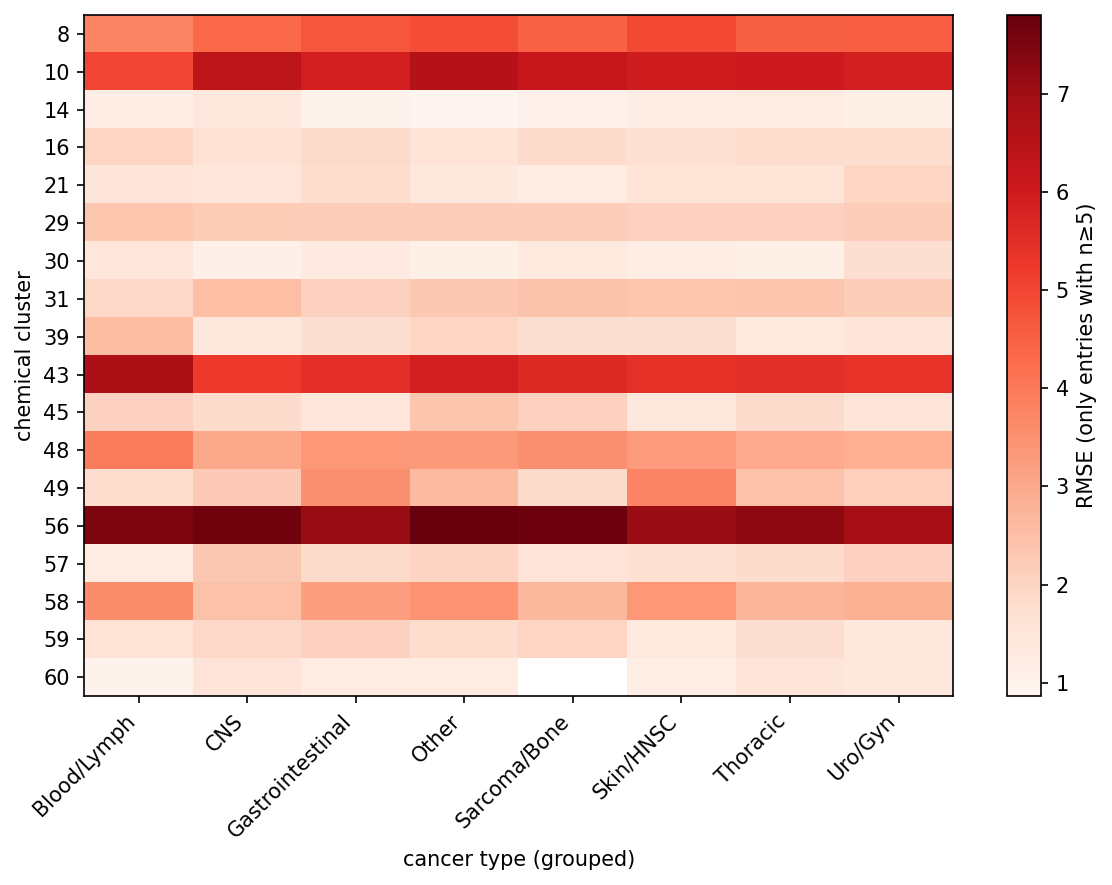


Proportion of explained error variance attributable to clusters:     0.752
Proportion of Explained Error Variance by Cancer Type:    0.001


In [151]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "META_CANCERTYPE" not in df.columns:
    category_map = {
        'T-Lymphoblastic Leukemia': 'Blood/Lymph', 'Acute Myeloid Leukemia': 'Blood/Lymph',
        'Chronic Myelogenous Leukemia': 'Blood/Lymph', 'B-Lymphoblastic Leukemia': 'Blood/Lymph',
        'Plasma Cell Myeloma': 'Blood/Lymph', "T-Cell Non-Hodgkin's Lymphoma": 'Blood/Lymph',
        "B-Cell Non-Hodgkin's Lymphoma": 'Blood/Lymph', "Burkitt's Lymphoma": 'Blood/Lymph',
        "Hodgkin's Lymphoma": 'Blood/Lymph', 'Other Blood Cancers': 'Blood/Lymph',
        'Colorectal Carcinoma': 'Gastrointestinal', 'Gastric Carcinoma': 'Gastrointestinal',
        'Pancreatic Carcinoma': 'Gastrointestinal', 'Hepatocellular Carcinoma': 'Gastrointestinal',
        'Biliary Tract Carcinoma': 'Gastrointestinal', 'Esophageal Carcinoma': 'Gastrointestinal',
        'Esophageal Squamous Cell Carcinoma': 'Gastrointestinal',
        'Non-Small Cell Lung Carcinoma': 'Thoracic', 'Squamous Cell Lung Carcinoma': 'Thoracic',
        'Small Cell Lung Carcinoma': 'Thoracic', 'Mesothelioma': 'Thoracic',
        "Ewing's Sarcoma": 'Sarcoma/Bone', 'Osteosarcoma': 'Sarcoma/Bone',
        'Chondrosarcoma': 'Sarcoma/Bone', 'Rhabdomyosarcoma': 'Sarcoma/Bone',
        'Other Sarcomas': 'Sarcoma/Bone',
        'Glioblastoma': 'CNS', 'Glioma': 'CNS', 'Neuroblastoma': 'CNS',
        'Ovarian Carcinoma': 'Uro/Gyn', 'Cervical Carcinoma': 'Uro/Gyn',
        'Endometrial Carcinoma': 'Uro/Gyn', 'Breast Carcinoma': 'Uro/Gyn',
        'Prostate Carcinoma': 'Uro/Gyn', 'Bladder Carcinoma': 'Uro/Gyn', 'Kidney Carcinoma': 'Uro/Gyn',
        'Melanoma': 'Skin/HNSC', 'Head and Neck Carcinoma': 'Skin/HNSC',
        'Oral Cavity Carcinoma': 'Skin/HNSC', 'Thyroid Gland Carcinoma': 'Skin/HNSC',
        'Non-Cancerous': 'Control', 'Other Solid Cancers': 'Other',
    }
    df["META_CANCERTYPE"] = df["CANCER_TYPE"].map(category_map).fillna("Other")

error_df["META_CANCERTYPE"] = df_test["META_CANCERTYPE"].values

def rmse(g):
    return np.sqrt((g["sq_error"]).mean())

rmse_by_cluster = error_df.groupby("cluster").apply(rmse).rename("RMSE_cluster")
rmse_by_cancer = error_df.groupby("META_CANCERTYPE").apply(rmse).rename("RMSE_cancertype")

print("RMSE by Cluster:\n", rmse_by_cluster.sort_values(ascending=False), "\n")
print("RMSE by Cancer type:\n", rmse_by_cancer.sort_values(ascending=False), "\n")

# heatmap
min_samples_cell = 5

pivot_counts = error_df.pivot_table(
    index="cluster", columns="META_CANCERTYPE", values="sq_error", aggfunc="count"
)
pivot_rmse = error_df.pivot_table(
    index="cluster", columns="META_CANCERTYPE", values="sq_error", aggfunc="mean"
) ** 0.5

valid_rows = (pivot_counts.fillna(0) >= min_samples_cell).any(axis=1)
valid_cols = (pivot_counts.fillna(0) >= min_samples_cell).any(axis=0)
pivot_rmse_masked = pivot_rmse.loc[valid_rows, valid_cols]
pivot_rmse_masked = pivot_rmse_masked.where(pivot_counts.loc[valid_rows, valid_cols] >= min_samples_cell)

fig, ax = plt.subplots(figsize=(max(8, 0.8 * len(pivot_rmse_masked.columns)),
                                 max(6, 0.3 * len(pivot_rmse_masked.index))), dpi=150)
im = ax.imshow(pivot_rmse_masked.values, cmap="Reds", aspect="auto")
ax.set_xticks(range(len(pivot_rmse_masked.columns)))
ax.set_xticklabels(pivot_rmse_masked.columns, rotation=45, ha="right")
ax.set_yticks(range(len(pivot_rmse_masked.index)))
ax.set_yticklabels(pivot_rmse_masked.index)
ax.set_xlabel("cancer type (grouped)")
ax.set_ylabel("chemical cluster")
plt.colorbar(im, ax=ax, label=f"RMSE (only entries with n≥{min_samples_cell})")
plt.tight_layout()
plt.show()

# decomposition of variance. What explains the error best?
def eta_squared(df_in, group_col, value_col="sq_error"):
    grand_mean = df_in[value_col].mean()
    ss_total = ((df_in[value_col] - grand_mean) ** 2).sum()
    group_means = df_in.groupby(group_col)[value_col].transform("mean")
    ss_between = ((group_means - grand_mean) ** 2).sum()
    return ss_between / ss_total

eta_cluster = eta_squared(error_df, "cluster")
eta_cancer = eta_squared(error_df, "META_CANCERTYPE")

print(f"\nProportion of explained error variance attributable to clusters:     {eta_cluster:.3f}")
print(f"Proportion of Explained Error Variance by Cancer Type:    {eta_cancer:.3f}")

You can see that the RMSE differs heavily between drug clusters from 1.14 to 7.24 but not that much between cancer types: 3.07 to 3.89.
That means that the model has systematic difficulties with specific drugs (their efficacy) und is robust to cancer types.

Look at "worst" drug clusters:

You see that there is a big range! Means that for some clusters the model can predict pretty well (R^2=0.38 !!) but others are terrible (--39,4...)

In [160]:
df_all = df.copy()
y_true = test_targets
y_pred = test_preds

error_df = pd.DataFrame({
    "DRUG_NAME": df_test["DRUG_NAME"].values,
    "cluster": df_test["cluster"].values,
    "META_CANCERTYPE": df_test["META_CANCERTYPE"].values,
    "y_true": y_true,
    "y_pred": y_pred,
})
error_df["abs_error"] = np.abs(error_df["y_true"] - error_df["y_pred"])
error_df["sq_error"] = (error_df["y_true"] - error_df["y_pred"]) ** 2

cluster_error_summary_oof = (
    error_df.groupby("cluster")
    .apply(cluster_metrics)
    .sort_values("R2", ascending=False)
)
print(cluster_error_summary_oof)

         n_samples  n_drugs      RMSE       MAE         R2
cluster                                                   
45           704.0      1.0  1.743322  1.401998   0.382854
30           666.0      1.0  1.375777  1.102461   0.294528
59           699.0      1.0  1.721459  1.361885   0.277309
21           573.0      1.0  1.691135  1.351694   0.148113
14           579.0      1.0  1.141658  0.919454   0.101310
16          1263.0      2.0  1.820539  1.603831   0.023334
31           705.0      1.0  2.205721  1.850932  -0.036153
57           705.0      1.0  1.817256  1.554690  -0.415579
60           176.0      1.0  1.337944  1.097194  -0.792061
29          2818.0      4.0  2.177074  1.773657  -0.844525
49           711.0      1.0  2.672207  2.156901  -1.212055
39           802.0      2.0  1.794079  1.555366  -1.514371
58           713.0      1.0  3.057372  2.863734  -4.630552
48           887.0      2.0  3.254395  2.964074  -5.646645
8            658.0      1.0  4.481594  4.360353  -8.0111

In [162]:
print(f"Drugs in cluster 45, the best by R^2: {error_df[error_df['cluster'] == 45]['DRUG_NAME'].unique().tolist()}")

Drugs in cluster 45, the best by R^2: ['Talazoparib']


In [163]:
print(f"Drugs in cluster 43, the worst by R^2: {error_df[error_df['cluster'] == 43]['DRUG_NAME'].unique().tolist()}")

Drugs in cluster 43, the worst by R^2: ['glutathione']
